<hr style="height:3px; background-color:black; border:none;">

<h3 style="text-align:center;">
A novel integrated logistic regression model enhanced with recursive feature elimination and explainable artificial intelligence for dementia prediction
</h3>

###### Authors: Rasel Ahmeda, Nafiz Fahada, Md Saef Ullah Miah, Md. Jakir Hossen, Md. Kishor Morol, Mufti Mahmud, M. Mostafizur Rahman
###### doi: https://doi.org/10.1016/j.health.2024.100362

<hr style="height:3px; background-color:black; border:none;">

### About the study:
- The authors have used a novel approach for predicting dementia using Logistic Regression model with enhanced Recursive Feature Elimination method, which helps in eliminating the least significant features and prevents overfitting.
- The model’s effectiveness was further assessed using metrics, including accuracy, precision, recall, F1-score, Matthews Correlation Coefficient (MCC), and Kappa score.
- SHapley Additive exPlanations (SHAP) values were also employed to improve the interpretability of the model, which provided the insights into the key features for dementia prediction. Here they have used a dataset with 1000 records where 50.5% are female and 49.06% are male and 24 features.

### Workflow:
1. Data preprocessing
2. Exploratory data analysis
3. Dataset is split to training and testing
4. Model-Based Feature selection using RFE+Logistic Regression
5. Model Building: Logistic Regression using hyperparameter tuning and training
6. Evaluation of Model using key metrics like accuracy, precision, recall, F1-score, Cohen Kappa score and Matthews Correlation Coefficient(MCC)
7. SHAP Analysis

<hr style="height:3px; background-color:black; border:none;">

In [137]:
# Installation of SHAP
!pip install -U shap

In [138]:
#Import Libraries
import numpy as np
import pandas as pd

# Model Training
from sklearn.model_selection import GridSearchCV, train_test_split

# Model
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_predict

# Visualization
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore Warings
import warnings
warnings.filterwarnings("ignore")

In [139]:
import random             # Generates random numbers
BATCH_SIZE = 32           # Number of samples being processed at one time during training
CHANNELS = 3              # Specifying image color channels(RGB)
EPOCHS = 5                # Number of times models will be passing through the entire dataset
                          #  during training

random.seed(42)           # Makes random outputs consistent and reproducible

<h2 style="color:#000080;">Load Dataset</h2>

In [140]:
df = pd.read_csv('dementia_patients_health_data.csv')
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [141]:
#Checking the age distributions of patients
print("Age Range:", df['Age'].min(), "to", df['Age'].max())

Age Range: 60 to 90


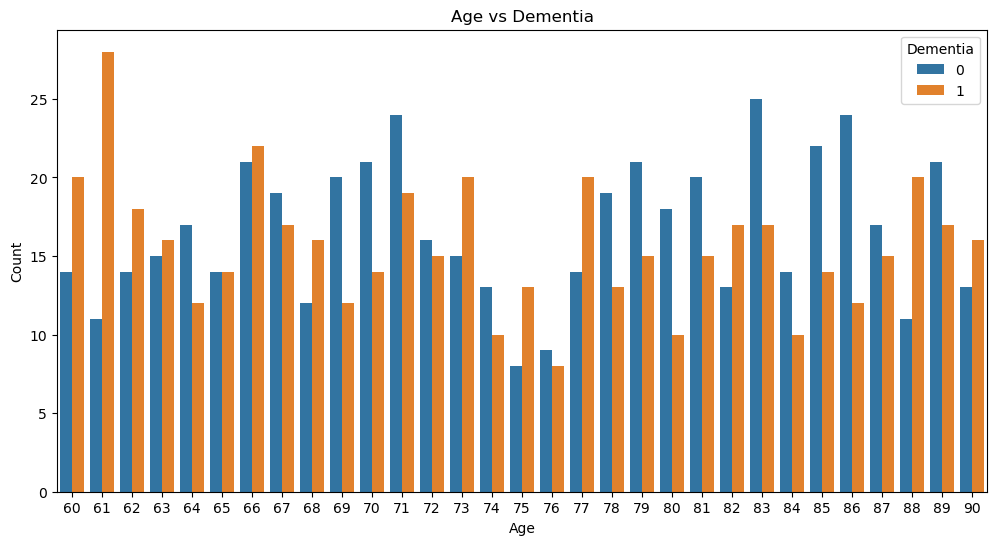

In [142]:
# Generating a count plot for checking how many individuals in a particular age(60 to 90) is having dementia and doesnot have dementa
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(x='Age', hue='Dementia', data=df, ax=ax)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age vs Dementia')
ax.legend(title='Dementia', loc='upper right')
plt.show()

#### Inference of the Count Plot:
- Here Orange bars(1) represents dementia cases and blue bars represents non-dementia cases(0)

In [143]:
# Checking number of missing values in each column of the input dataset
df.isnull().sum()

Diabetic                       0
AlcoholLevel                   0
HeartRate                      0
BloodOxygenLevel               0
BodyTemperature                0
Weight                         0
MRI_Delay                      0
Prescription                 515
Dosage in mg                 515
Age                            0
Education_Level                0
Dominant_Hand                  0
Gender                         0
Family_History                 0
Smoking_Status                 0
APOE_ε4                        0
Physical_Activity              0
Depression_Status              0
Cognitive_Test_Scores          0
Medication_History             0
Nutrition_Diet                 0
Sleep_Quality                  0
Chronic_Health_Conditions    179
Dementia                       0
dtype: int64

#### Inferences:
- Missing values in Prescription and Dosage in mg is high (515 values each).
- Chronic_Health_Conditions has 179 missing values.
- These are handled in later stage.

In [144]:
# Fill numeric NaNs with mean
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [145]:
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,9.213402,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.000000,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,9.213402,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.000000,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.000000,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [146]:
df.columns

Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription',
       'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender',
       'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity',
       'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History',
       'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions',
       'Dementia'],
      dtype='object')

In [147]:
df.shape

(1000, 24)

In [148]:
#Checking the missing value again after filling the numeric NaNs with mean
df.isnull().sum()

Diabetic                       0
AlcoholLevel                   0
HeartRate                      0
BloodOxygenLevel               0
BodyTemperature                0
Weight                         0
MRI_Delay                      0
Prescription                 515
Dosage in mg                   0
Age                            0
Education_Level                0
Dominant_Hand                  0
Gender                         0
Family_History                 0
Smoking_Status                 0
APOE_ε4                        0
Physical_Activity              0
Depression_Status              0
Cognitive_Test_Scores          0
Medication_History             0
Nutrition_Diet                 0
Sleep_Quality                  0
Chronic_Health_Conditions    179
Dementia                       0
dtype: int64

##### From the above results, we can see that Dosage in mg being a numerical column, the NaNs has been replaced by mean value

<hr style="border-top: 2px dotted gray;">

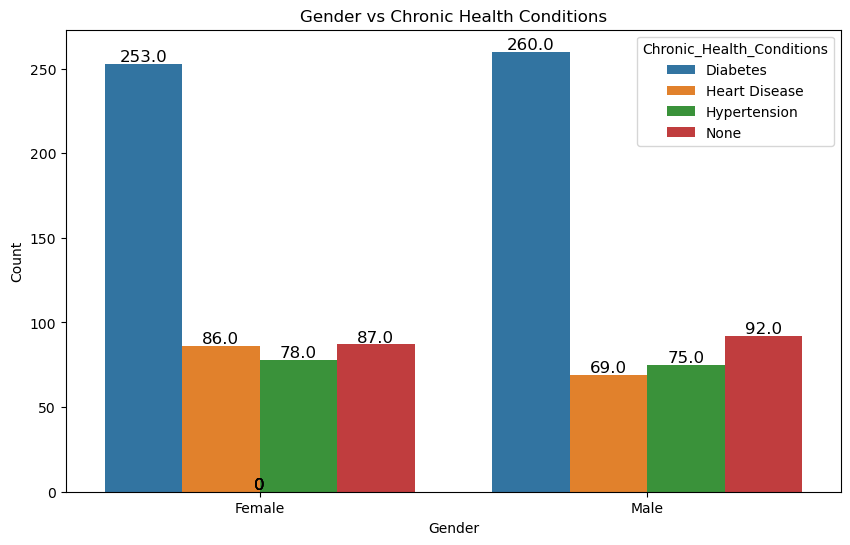

In [221]:
# Grouping the patients by Gender and Chronic_Health_Conditions to analyze the patients falling to each category

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['Chronic_Health_Conditions'] = df['Chronic_Health_Conditions'].fillna('None')
# Count the number of patients with each gender and chronic health condition
gender_chronic_counts = df.groupby(['Gender', 'Chronic_Health_Conditions'], dropna=False).size().reset_index(name='count')


# Create a bar plot of the counts
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='count', hue='Chronic_Health_Conditions', data=gender_chronic_counts)

# Add the count labels on top of the bars
for p in plt.gca().patches:
    count = p.get_height()
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(count, (x, y), ha='center', va='center', size=12, xytext=(0, 5), textcoords='offset points')

# Set the title and labels
plt.title('Gender vs Chronic Health Conditions')
plt.xlabel('Gender')
plt.ylabel('Count')

# Display the plot
plt.show()

#### Inference from the plot:
- In both the genders, people with diabetes are high.
- Diabetes is more prevalent in male compared to females
- Heart disease can be seen more in females
- The rest are people with no chronic health conditions

<hr style="border-top: 2px dotted gray;">

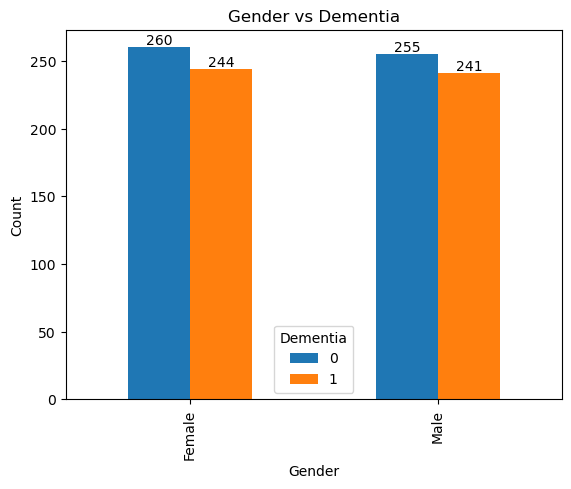

In [150]:
#Creation of a cross tabulation between Gender and Dementia 

# Create a crosstab table of gender vs Dementia
crosstab = pd.crosstab(df['Gender'], df['Dementia'])

# Create a bar chart of the crosstab table
fig, ax = plt.subplots()
crosstab.plot(kind='bar', ax=ax)

# Add the number of patients above each bar
for i in ax.patches:
    ax.annotate(str(i.get_height()), (i.get_x() + i.get_width() / 2., i.get_height()),
                ha='center', va='bottom')

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender vs Dementia')
plt.show()

#### Inference from the Plot:
- Out of 504 females, 260 is not having Dementia and rest 244 is with Dementia.
- Out of 496 males, 255 is not having Dementia and rest 241 is with Dementia.
- Therefore the population without Dementia is slightly higher than the population with Dementia.
- The difference with people having dementia in both the genders is not much significant.

<hr style="border-top: 2px dotted gray;">

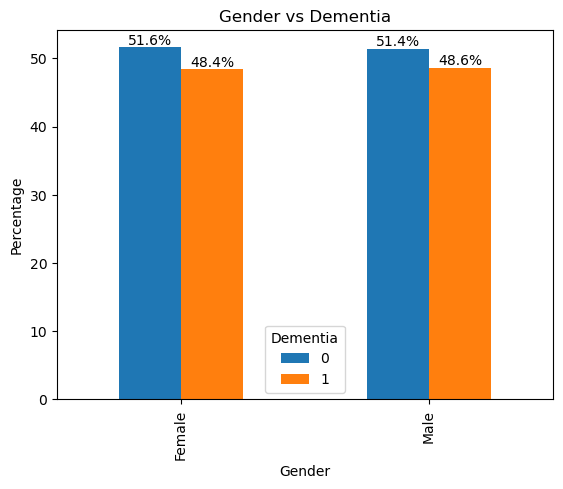

In [151]:
# Creating a cross-tabulation between Gender and Dementia but here percentage is being calculated

# Create a crosstab table of gender vs Dementia
crosstab = pd.crosstab(df['Gender'], df['Dementia'])

# Calculate the percentage
crosstab_percent = crosstab.div(crosstab.sum(1), axis=0) * 100

# Create a bar chart of the crosstab table
fig, ax = plt.subplots()
crosstab_percent.plot(kind='bar', ax=ax)

# Add the percentage of patients above each bar
for i in ax.patches:
    # Get the height of the bar
    height = i.get_height()
    # Calculate the percentage
    percentage = '{:.1f}%'.format(height)
    # Annotate the percentage on the bar
    ax.annotate(percentage, (i.get_x() + i.get_width() / 2., height),
                ha='center', va='bottom')

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.title('Gender vs Dementia')
plt.show()

#### Inference of the plot:
- Percentage of people without dementia is more than that of people with dementia for both male and female.


<hr style="border-top: 2px dotted gray;">

In [152]:
# Total number of male and female in gender feature
gender_counts = df['Gender'].value_counts()
male_count = gender_counts['Male']
female_count = gender_counts['Female']

# Percentage of male and female
male_percent = (male_count / len(df)) * 100
female_percent = (female_count / len(df)) * 100

# Print the results
print(f"Total number of male: {male_count}")
print(f"Total number of female: {female_count}")
print(f"Percentage of male: {male_percent:.2f}%")
print(f"Percentage of female: {female_percent:.2f}%")


Total number of male: 496
Total number of female: 504
Percentage of male: 49.60%
Percentage of female: 50.40%


<h2 style="color:#000080;">Data Preprocessing</h2>

In [153]:
#Creating a copy of the original dataset
data = df.copy()

In [154]:
data.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,9.213402,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.000000,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,9.213402,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.000000,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.000000,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [155]:
# check null values
data.isnull().any()

Diabetic                     False
AlcoholLevel                 False
HeartRate                    False
BloodOxygenLevel             False
BodyTemperature              False
Weight                       False
MRI_Delay                    False
Prescription                  True
Dosage in mg                 False
Age                          False
Education_Level              False
Dominant_Hand                False
Gender                       False
Family_History               False
Smoking_Status               False
APOE_ε4                      False
Physical_Activity            False
Depression_Status            False
Cognitive_Test_Scores        False
Medication_History           False
Nutrition_Diet               False
Sleep_Quality                False
Chronic_Health_Conditions     True
Dementia                     False
dtype: bool

In [156]:
#Unique values within each of the columns are extracted and printed
categorical_columns = ["Prescription","Education_Level","Dominant_Hand", "Gender", "Family_History", "Smoking_Status", "APOE_ε4", "Medication_History", "Nutrition_Diet", "Sleep_Quality", "Chronic_Health_Conditions", "Physical_Activity", "Depression_Status"]

for i in categorical_columns:
    print(data[i].unique())

[nan 'Galantamine' 'Donepezil' 'Memantine' 'Rivastigmine']
['Primary School' 'Secondary School' 'No School' 'Diploma/Degree']
['Left' 'Right']
['Female' 'Male']
['No' 'Yes']
['Current Smoker' 'Former Smoker' 'Never Smoked']
['Negative' 'Positive']
['No' 'Yes']
['Low-Carb Diet' 'Mediterranean Diet' 'Balanced Diet']
['Poor' 'Good']
['Diabetes' 'Heart Disease' 'Hypertension' nan]
['Sedentary' 'Moderate Activity' 'Mild Activity']
['No' 'Yes']


<h2 style="color:#000080;">Label Encoding</h2>

In [157]:
# Label Encoding is done for all the categorical columns in the dataset
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for i in categorical_columns:
    data[i] = encoder.fit_transform(df[i])

In [158]:
# Handling missing values in Prescription column
data['Prescription'].fillna(data['Prescription'].mean(), inplace=True)

In [159]:
#Checking for missing column
data.isnull().any()

Diabetic                     False
AlcoholLevel                 False
HeartRate                    False
BloodOxygenLevel             False
BodyTemperature              False
Weight                       False
MRI_Delay                    False
Prescription                 False
Dosage in mg                 False
Age                          False
Education_Level              False
Dominant_Hand                False
Gender                       False
Family_History               False
Smoking_Status               False
APOE_ε4                      False
Physical_Activity            False
Depression_Status            False
Cognitive_Test_Scores        False
Medication_History           False
Nutrition_Diet               False
Sleep_Quality                False
Chronic_Health_Conditions    False
Dementia                     False
dtype: bool

<Axes: >

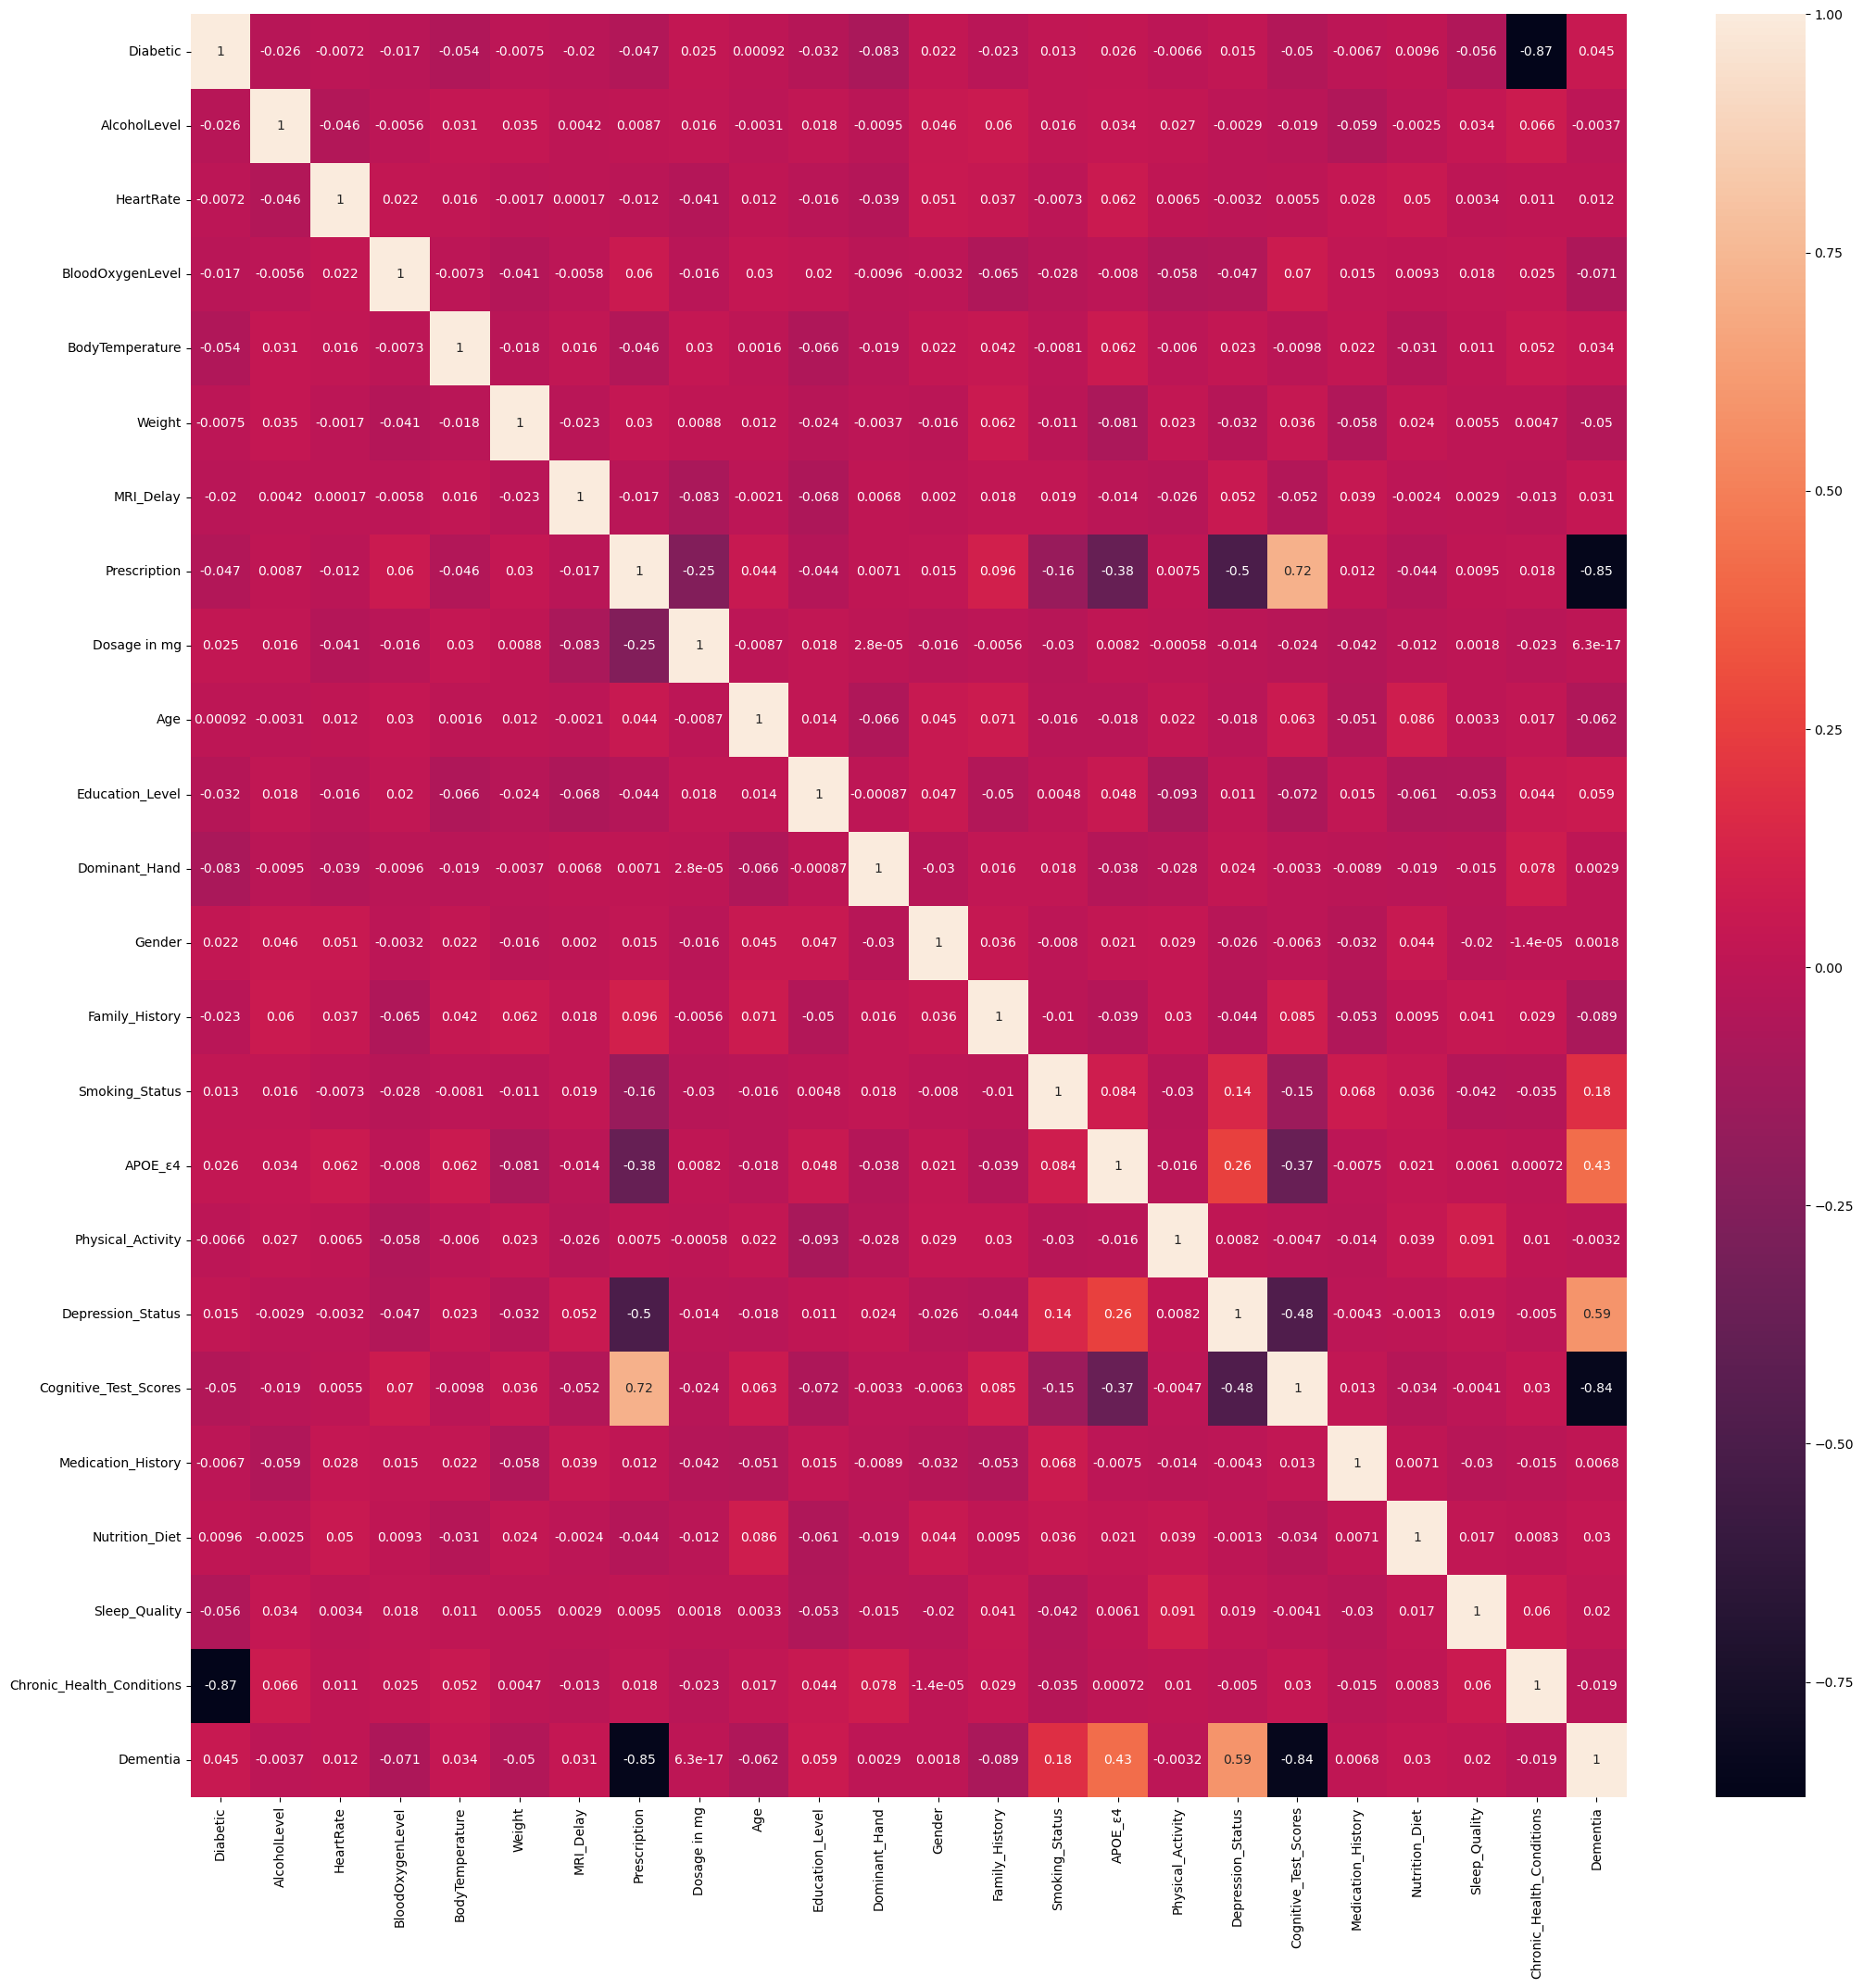

In [160]:
#Visualizing correlation between variables in the dataset using heatmap
plt.figure(figsize=(25,25))
sns.heatmap(data.corr(), annot=True)

### Inference of the heatmap:
##### How to infer?
- +1 denotes perfect positive relationship
- -1 is the perfect negative relationship
- 0 denotes no linear relationship
Correlation Value	Meaning
- +0.5 and above indicates strong positive relationship
- -0.5 and above indicates strong negative relationship

##### Inference:
- Depression Status:0.59 indicates strong link to dementia
- APOE_ε4 Gene:0.43 indicates this genetic factor has a great influence on dementia risk
- Cognitive Test Scores:−0.84 and prescription:-0.85 has strong negative relationship with the dementia
- Gender,Weight, Age, Education Level has weak correlation with dementia


In [161]:
#Preprocessing of numerical columns before implementing the ML model
from sklearn.preprocessing import StandardScaler
import numpy as np

numerical_columns = ["AlcoholLevel", "HeartRate", "BloodOxygenLevel", "BodyTemperature", "Weight", "MRI_Delay", "Dosage in mg", "Age", "Cognitive_Test_Scores"]

scaler = StandardScaler()

# Convert non-numeric values to NaN
data[numerical_columns] = data[numerical_columns].apply(pd.to_numeric, errors='coerce')

# Now, handle missing values (you can use other imputation methods if needed)
data[numerical_columns] = data[numerical_columns].fillna(data[numerical_columns].mean())

# Apply StandardScaler(Feature Scaling)
for col in numerical_columns:
    data[col] = scaler.fit_transform(np.array(data[col]).reshape(-1, 1))

In [162]:
data.shape

(1000, 24)

<h2 style="color:#000080;">Train Test</h2>

In [163]:
from sklearn.linear_model import LogisticRegression #Importing LogisticRegression
from sklearn.model_selection import train_test_split #For splitting dataset into testing and training data
from sklearn.metrics import accuracy_score #Importing accuracy_score, for measuring accuracy of model's predictions

In [164]:
#Viewing dataset columns
data.columns

Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription',
       'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender',
       'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity',
       'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History',
       'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions',
       'Dementia'],
      dtype='object')

In [165]:
X = data.drop(columns='Dementia', axis=1) #Input features
y = data['Dementia'] #Target feature

In [166]:
#Splitting the data into training and testing datasets
X_train, X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [167]:
# Converting the target variable from 1D array to 2D column vector
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

#Displaying shape of the dataset
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (800, 23)
X_test shape: (200, 23)
y_train shape: (800, 1)
y_test shape: (200, 1)


In [168]:
data.shape

(1000, 24)

In [169]:
# Displaying the class distribution of target variable(0:without dementia,1:with dementia)
class_counts = y.value_counts()
print(class_counts)

Dementia
0    515
1    485
Name: count, dtype: int64


In [170]:
# Descriptive statistical analysis for numerical features
numerical_features = X.select_dtypes(include=['int64', 'float64'])
print(numerical_features.describe())

          Diabetic  AlcoholLevel     HeartRate  BloodOxygenLevel  \
count  1000.000000  1.000000e+03  1.000000e+03      1.000000e+03   
mean      0.513000  4.263256e-17  3.694822e-16      1.614708e-15   
std       0.500081  1.000500e+00  1.000500e+00      1.000500e+00   
min       0.000000 -1.670179e+00 -1.601702e+00     -1.781330e+00   
25%       0.000000 -9.018290e-01 -9.406272e-01     -8.030045e-01   
50%       1.000000 -3.317024e-03 -3.164897e-02      5.614099e-02   
75%       1.000000  9.101075e-01  8.773292e-01      8.740565e-01   
max       1.000000  1.728480e+00  1.703673e+00      1.630297e+00   

       BodyTemperature        Weight     MRI_Delay  Prescription  \
count     1.000000e+03  1.000000e+03  1.000000e+03   1000.000000   
mean      6.188827e-15  1.936229e-16  3.552714e-17      2.798000   
std       1.000500e+00  1.000500e+00  1.000500e+00      1.456474   
min      -1.759979e+00 -1.677553e+00 -1.780548e+00      0.000000   
25%      -8.485812e-01 -8.946812e-01 -8.227372e

In [171]:
# Print the count of each unique value for each feature, also checking the type of the column
for column in X.columns:
    print(X[column].value_counts())

Diabetic
1    513
0    487
Name: count, dtype: int64
AlcoholLevel
-0.212317    1
-0.229285    1
-1.388015    1
-1.523866    1
-0.204344    1
            ..
-1.198797    1
-0.268517    1
-0.527279    1
-0.018570    1
-1.408778    1
Name: count, Length: 1000, dtype: int64
HeartRate
-1.601702    32
 0.877329    31
-0.692724    31
 1.621039    31
 1.125232    31
-1.353799    30
-1.023262    29
 0.133620    28
-1.105896    28
-0.940627    28
-0.444821    28
-1.188530    28
-0.031649    27
-1.436433    27
-1.271165    26
 0.629426    26
 1.042598    26
 1.207867    25
-1.519068    25
 0.381523    25
-0.114283    24
-0.610090    24
-0.857993    24
 0.794695    24
 1.455770    24
 0.216254    23
 1.290501    23
-0.362186    22
 1.538404    21
 0.959964    21
-0.527455    20
 1.703673    20
 0.298889    20
 0.546792    20
 0.050985    20
-0.196918    19
 0.712060    19
-0.775358    19
-0.279552    18
 1.373136    17
 0.464157    16
Name: count, dtype: int64
BloodOxygenLevel
 0.101364    1
 0.34

<h2 style="color:#000080;">Test</h2>

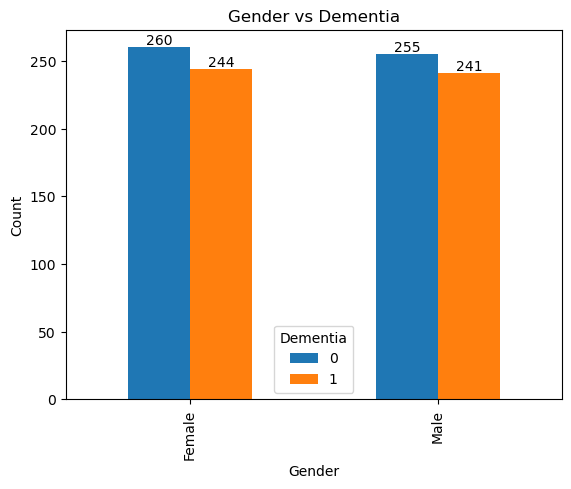

In [172]:
#Performing bivariate categorical analysis 
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab table of gender vs Dementia
crosstab = pd.crosstab(df['Gender'], df['Dementia'])

# Create a bar chart of the crosstab table
fig, ax = plt.subplots()
crosstab.plot(kind='bar', ax=ax)

# Add the number of patients above each bar
for i in ax.patches:
    ax.annotate(str(i.get_height()), (i.get_x() + i.get_width() / 2., i.get_height()),
                ha='center', va='bottom')

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender vs Dementia')
plt.show()

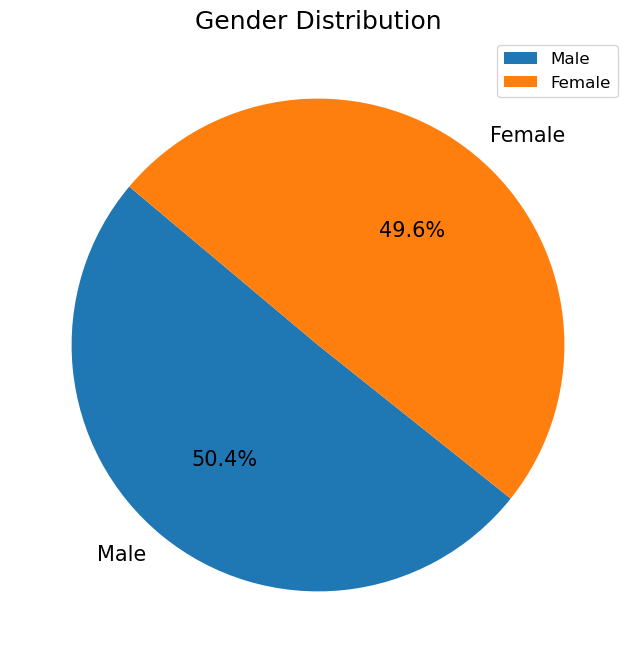

In [173]:
import matplotlib.pyplot as plt
# Create a pie chart to visualize the number of male and female
plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=['Male', 'Female'], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 15})
plt.title('Gender Distribution', fontsize=18)
# Increase the font size of labels
plt.legend(fontsize=12)
plt.show()

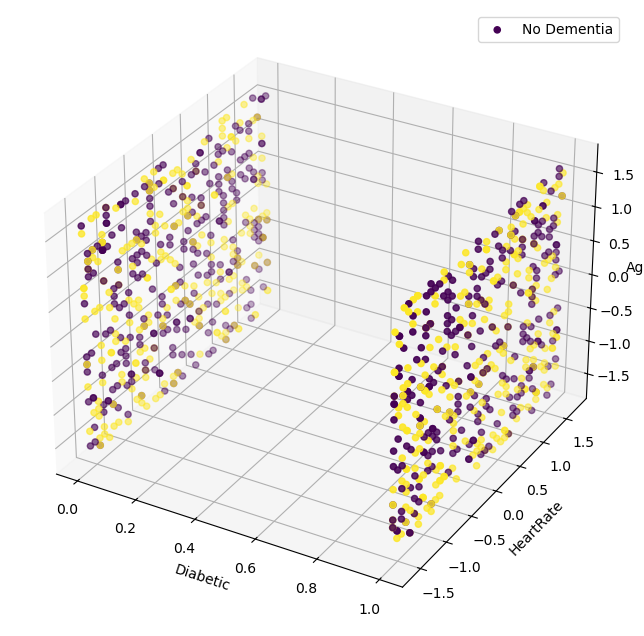

In [174]:
#Creating 3D scatter plot to visually exploring the relationship between the three selected features which are
# Diabetic,HeartRate,Age and Dementia
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Select three features for the 3D plot
features = ['Diabetic', 'HeartRate', 'Age']

# Scatter plot of the selected features
ax.scatter(X[features[0]], X[features[1]], X[features[2]], c=y, cmap='viridis')

# Set axis labels and title
ax.set_xlabel(features[0])
ax.set_ylabel(features[1])
ax.set_zlabel(features[2], labelpad=.01)
#ax.set_title('3D Visualization of Dementia Dataset')

# Add a legend for the target variable
plt.legend(['No Dementia', 'Dementia'])

# Display the plot
plt.show()

### Inference from the plot:
- X axis: Diabetes, Y axis:HeartRate, Z axis:Age
- Purple and yellow are two classes of Dementia
- The selected features alone doesnt define Dementia properly, other features are needed to be taken

<h2 style="color:#000080;">Dataset Analysis</h2>

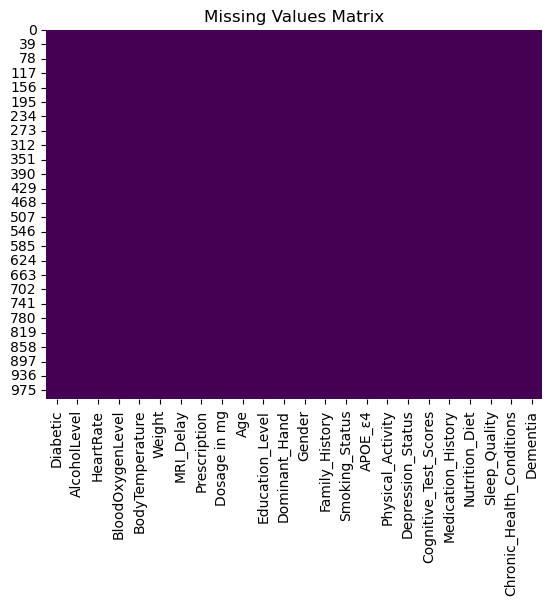

In [175]:
#To confirm whether dataset has any missing values
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Matrix')
plt.show()

#### Inference:
-  Features are in the x-axis, data records are in the y-axis
-  Uniform colour shows that no missing values are present

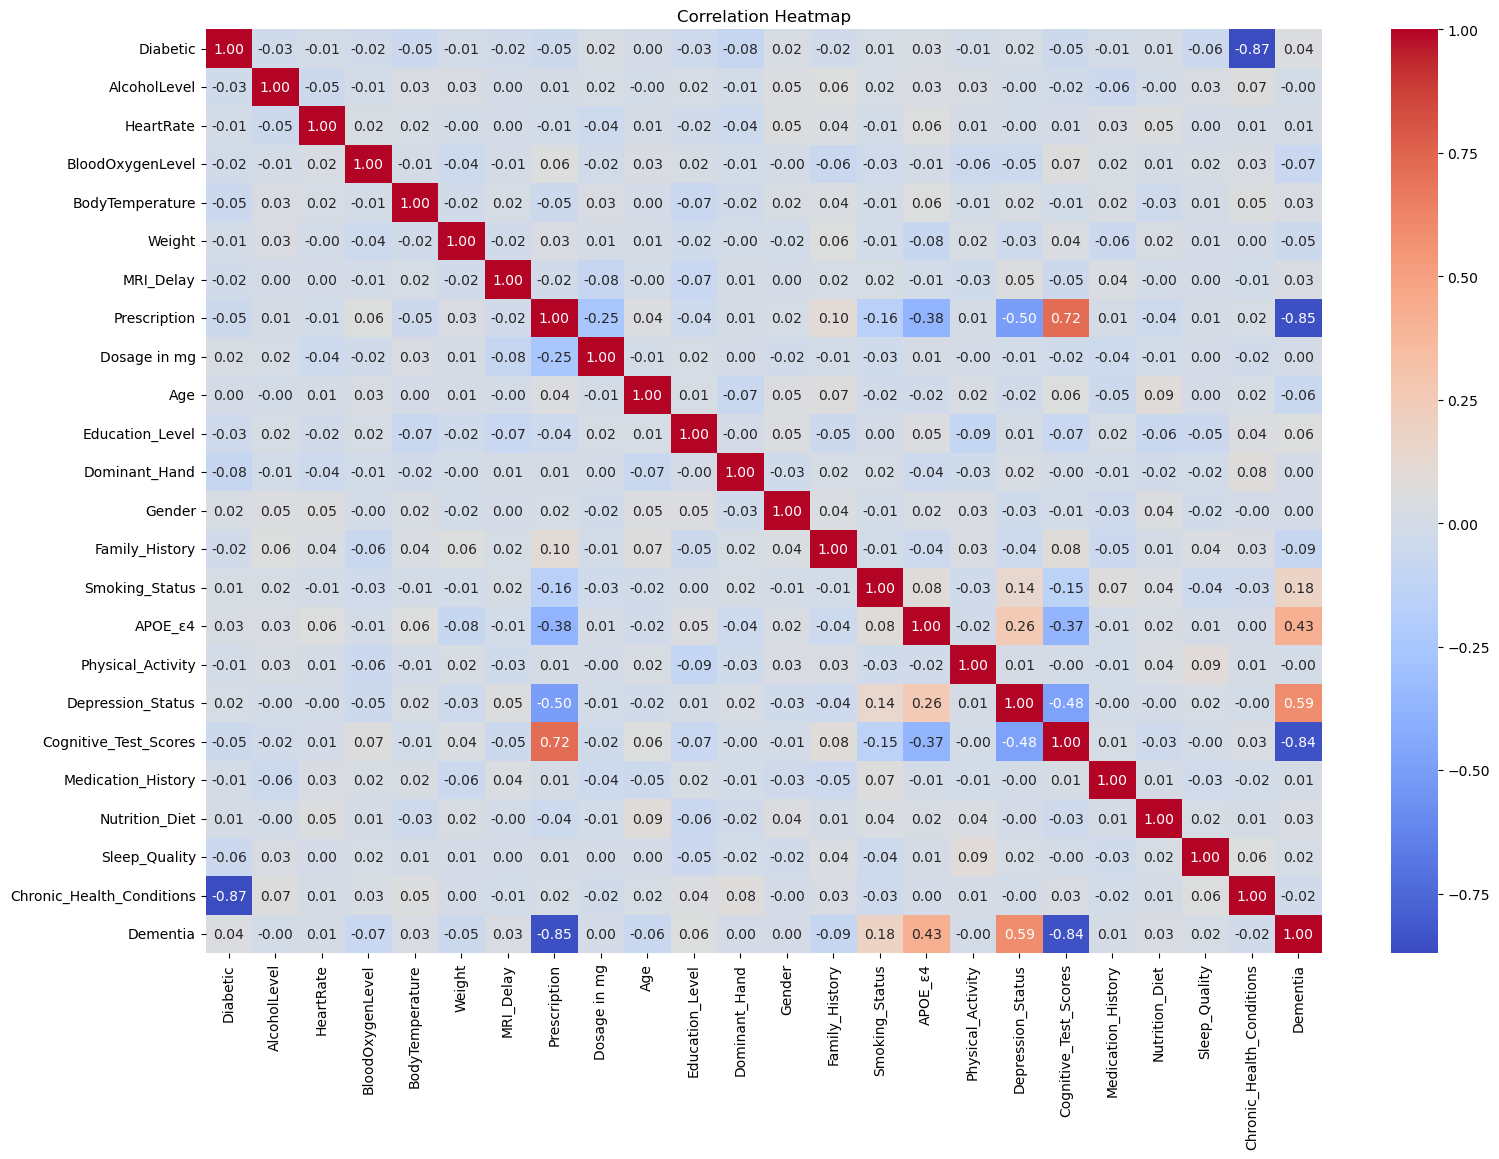

In [176]:
#Finding the correlation between the features
correlation_matrix = data.corr()
plt.figure(figsize=(18,12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Inference
- As previously analyzed, Depression Status and APOE_E4 are highly important features for dementia prediction


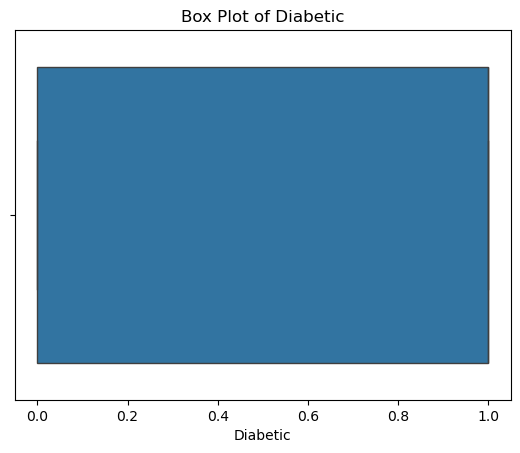

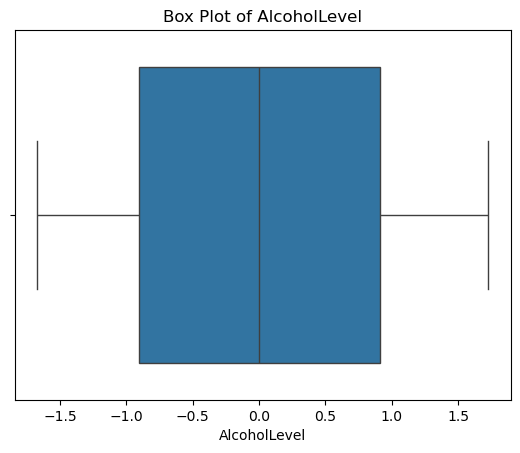

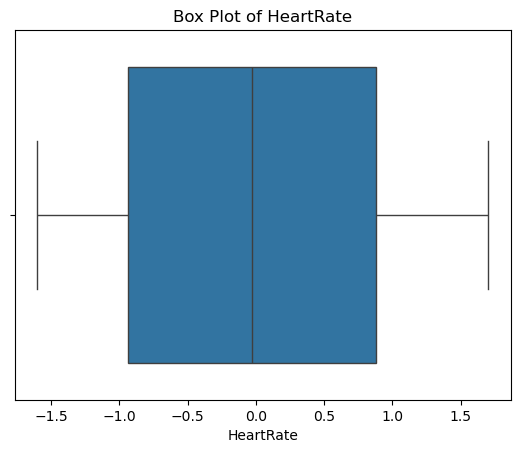

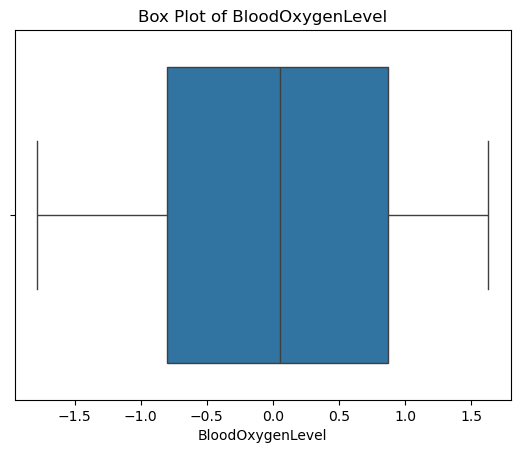

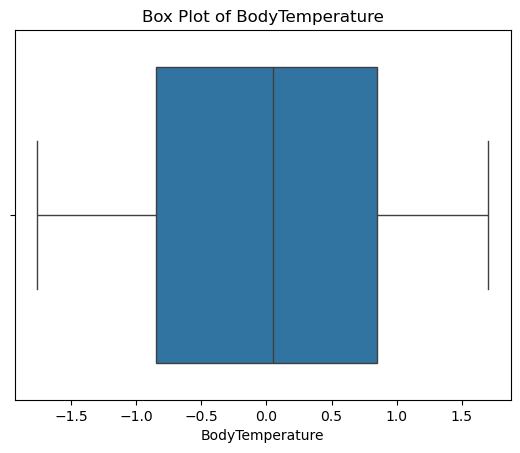

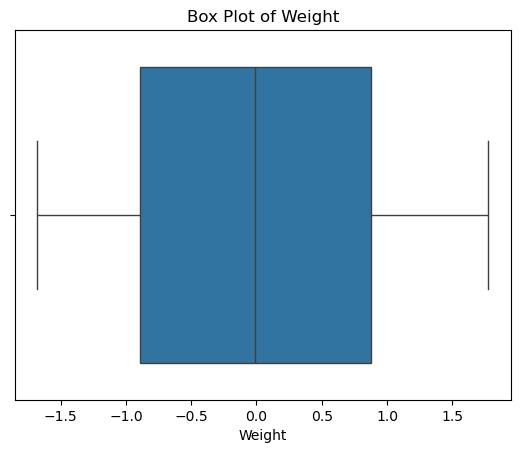

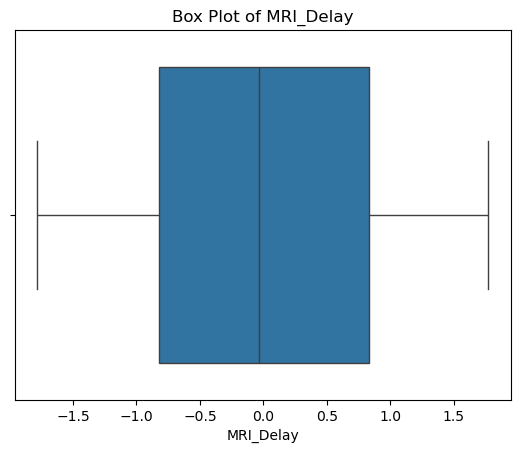

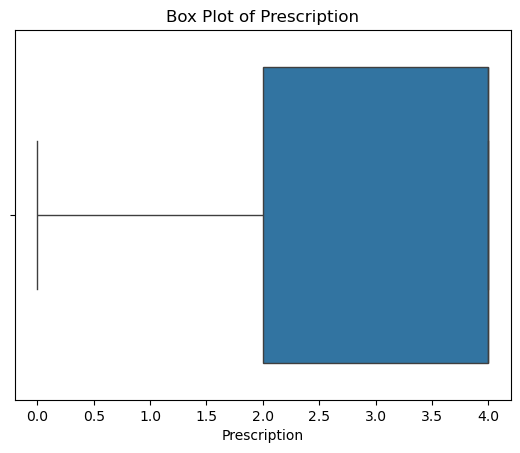

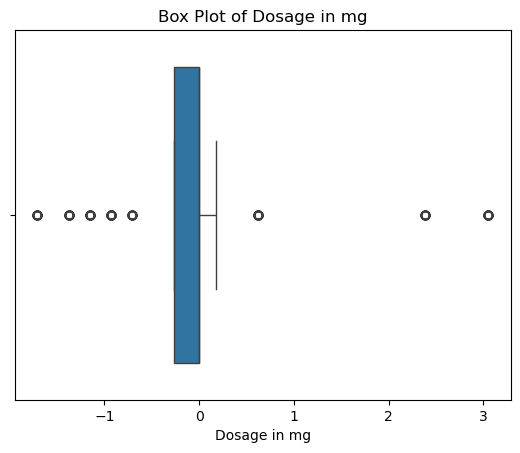

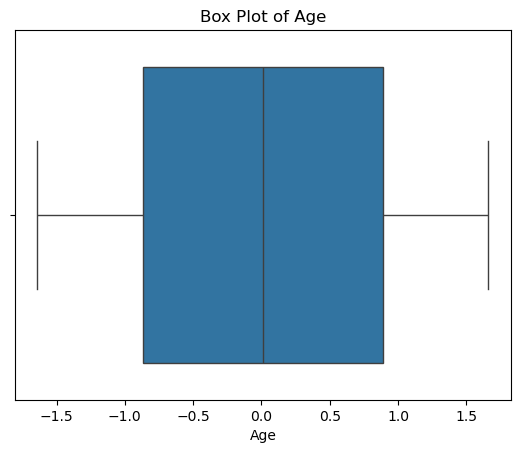

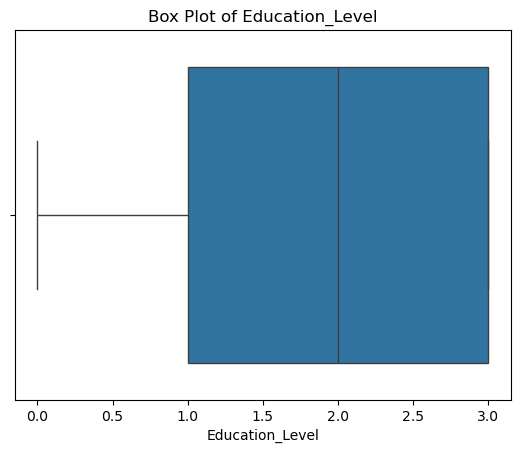

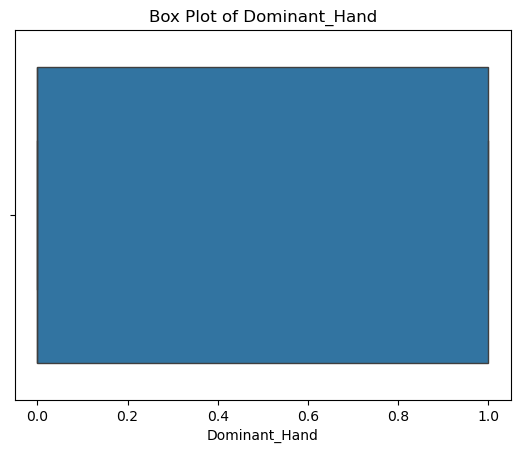

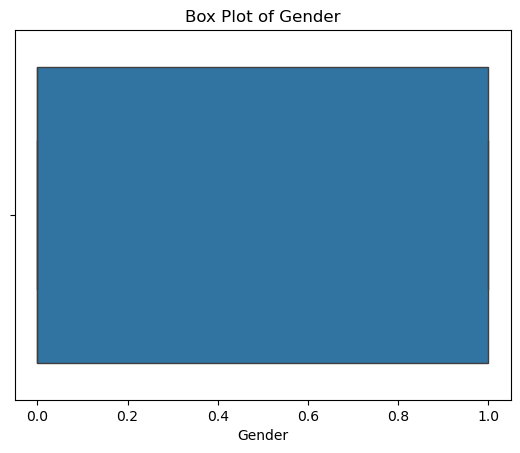

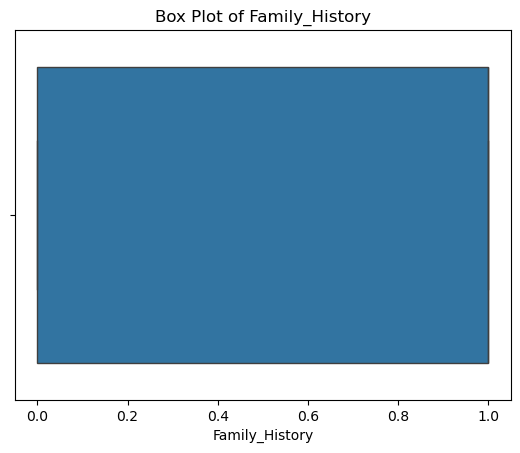

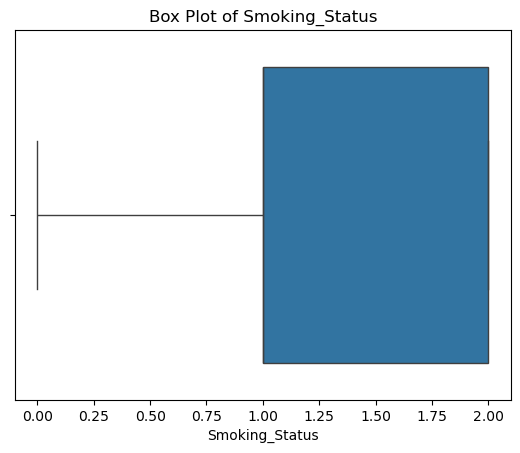

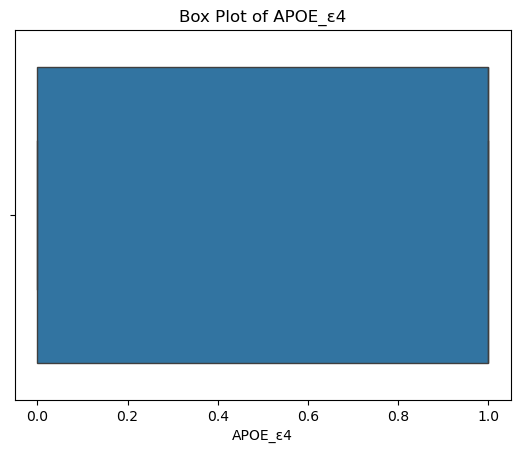

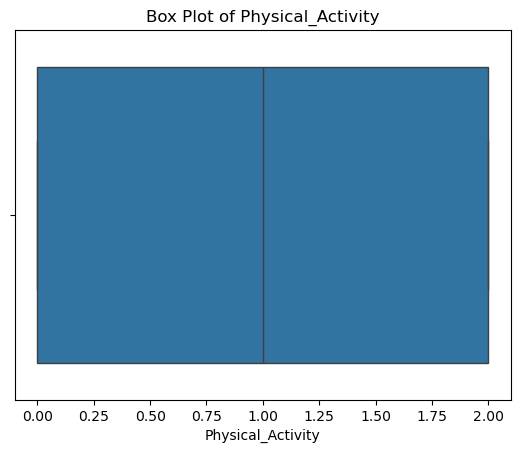

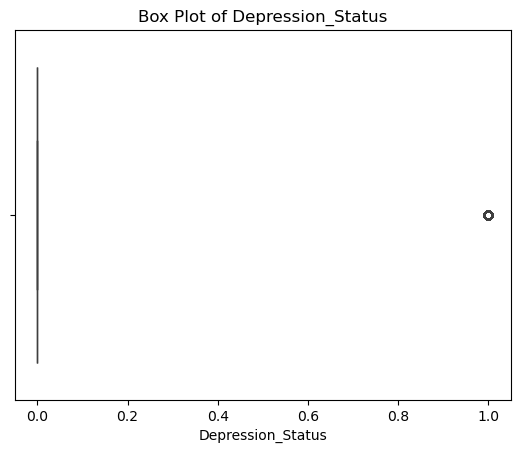

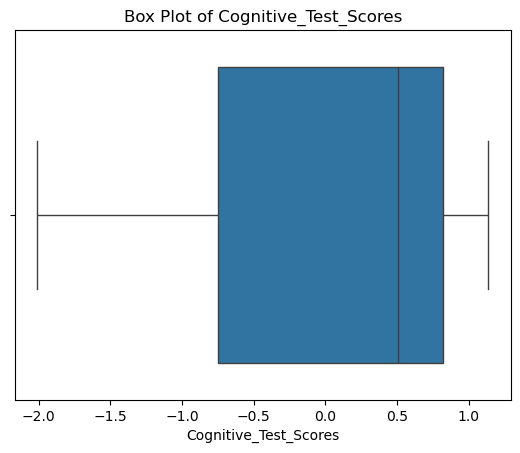

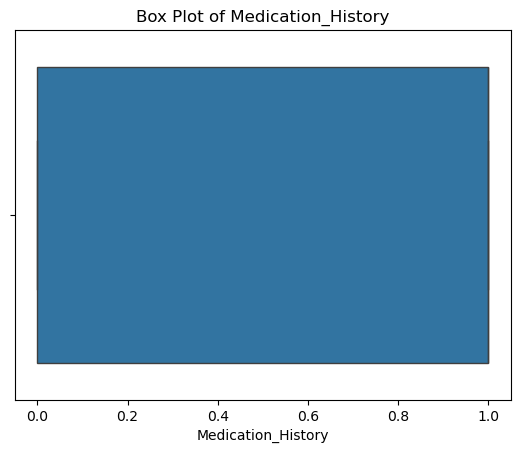

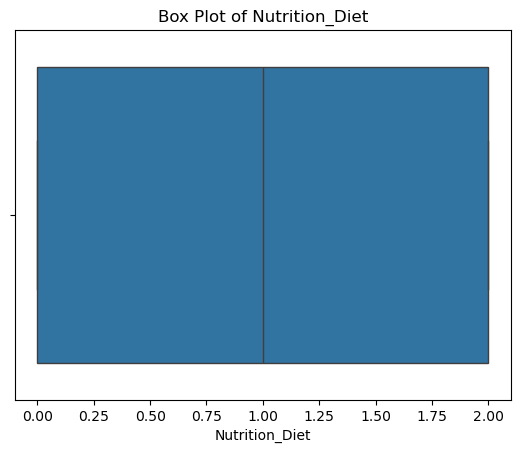

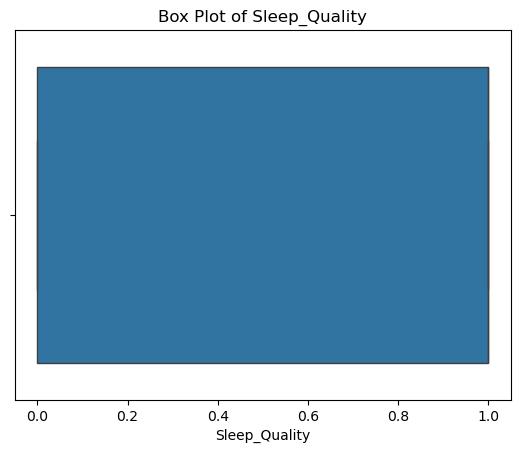

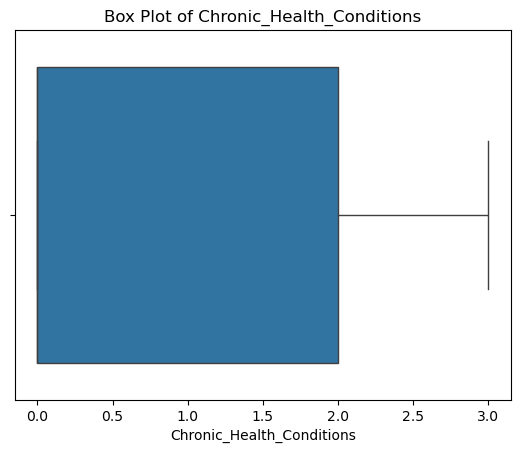

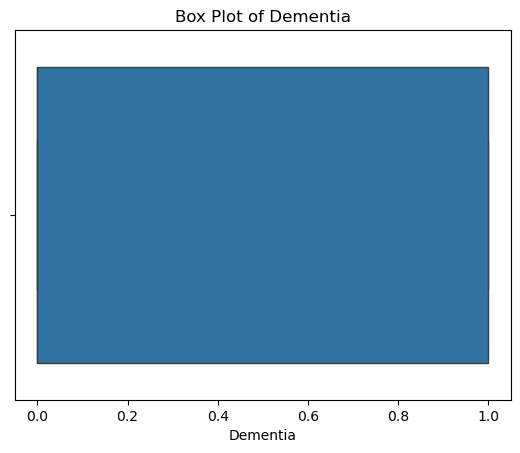

In [177]:
#Box plot is generated for each numerical columns in the dataset, for detecting any outlier and distribution
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
for column in numerical_columns:
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

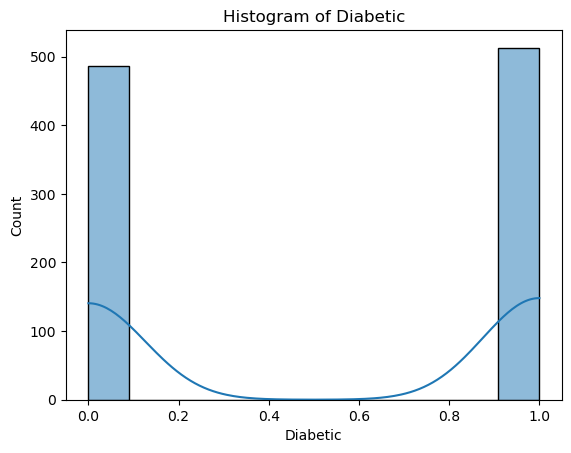

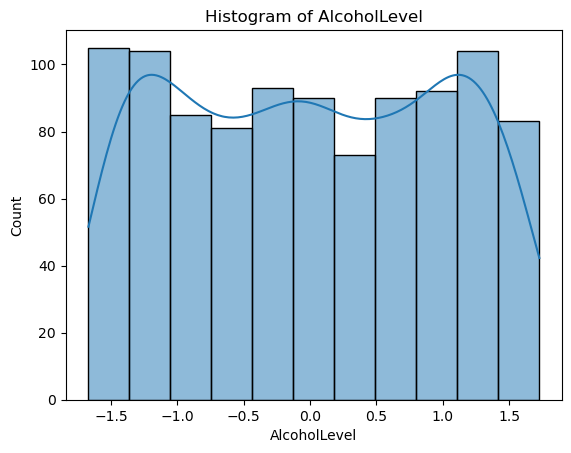

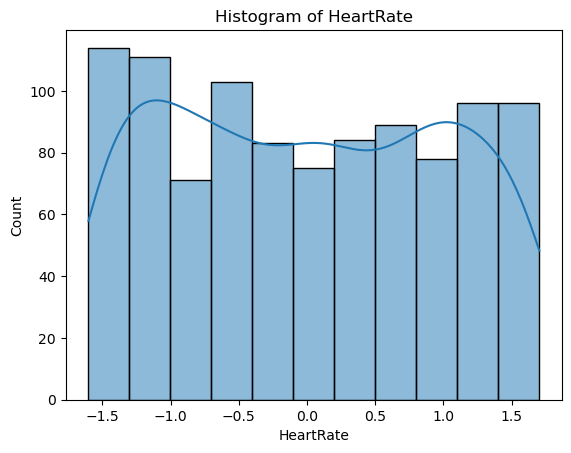

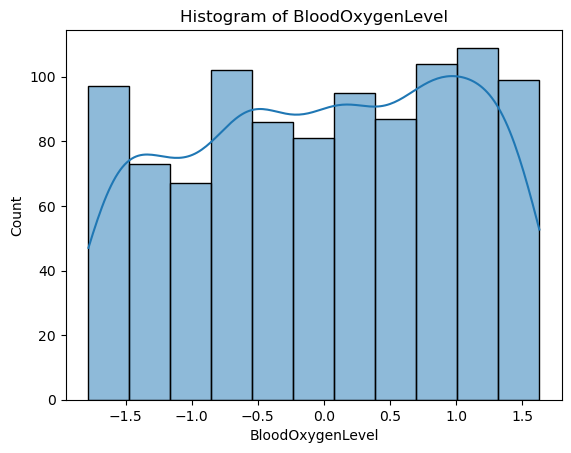

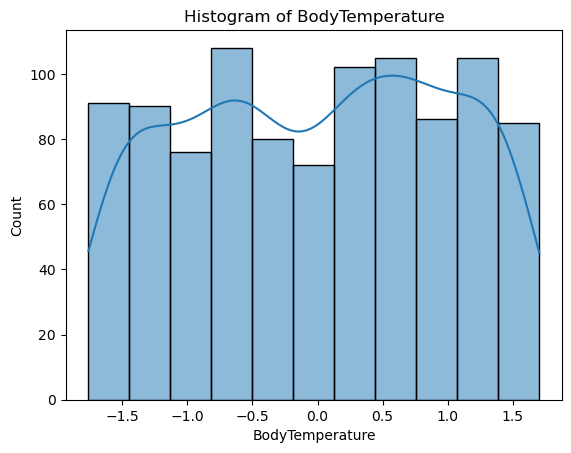

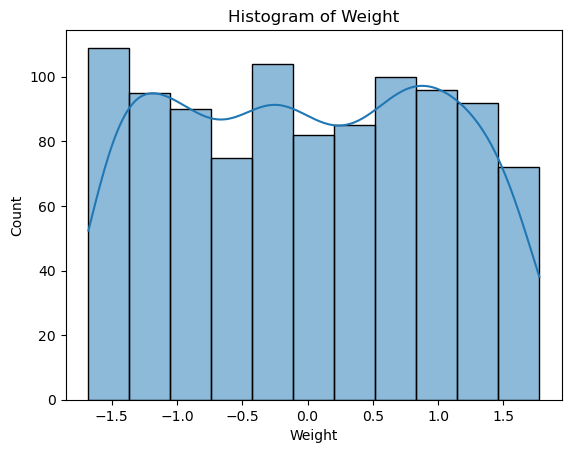

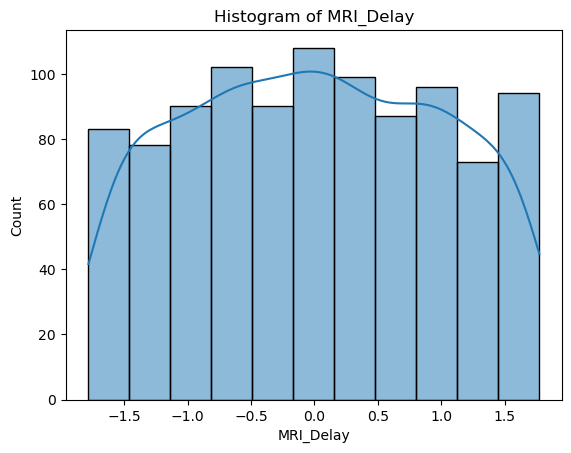

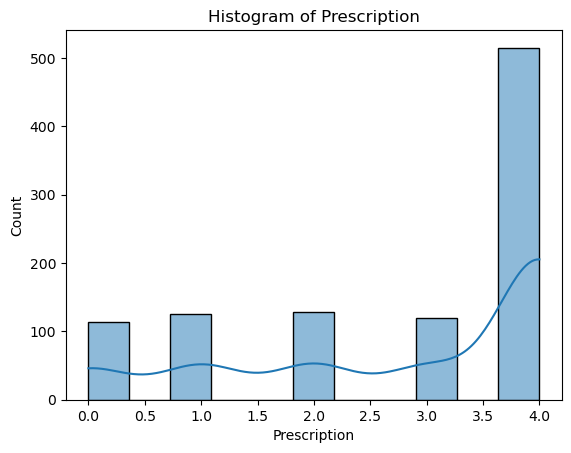

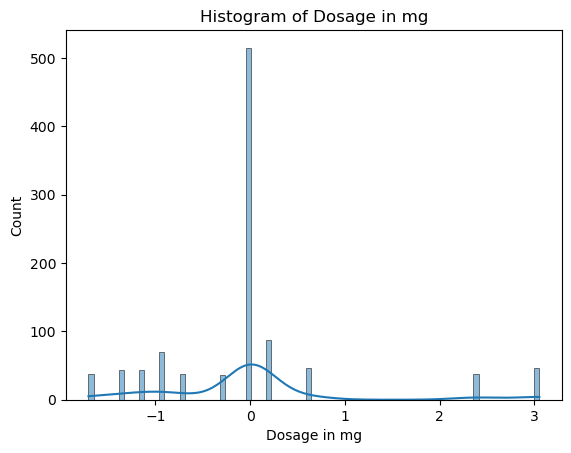

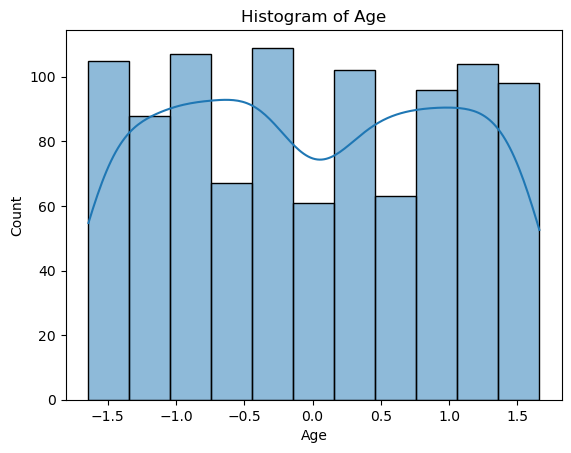

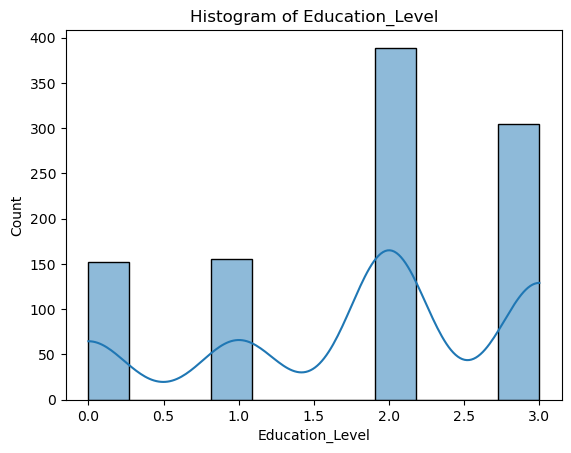

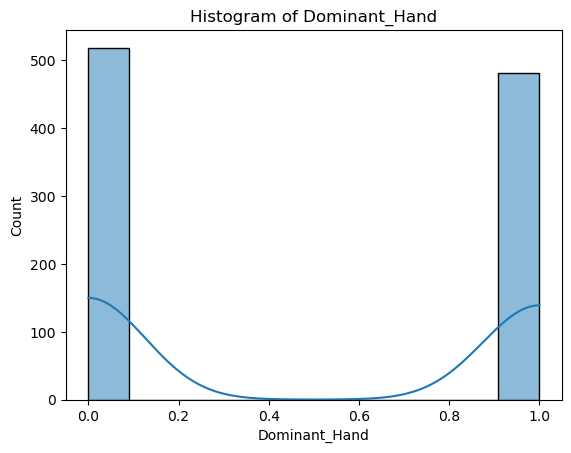

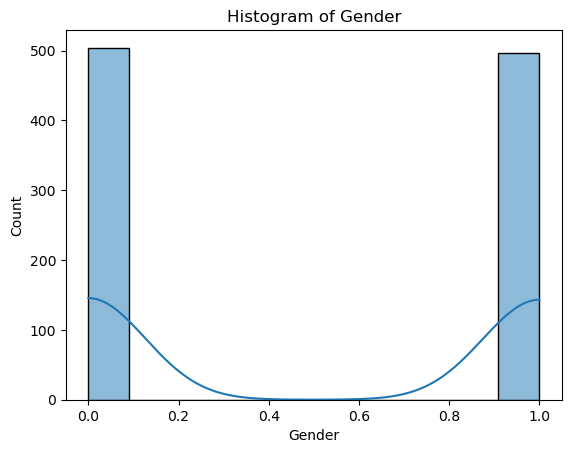

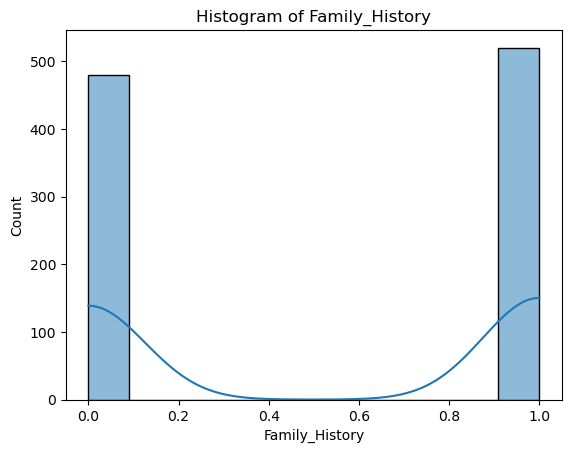

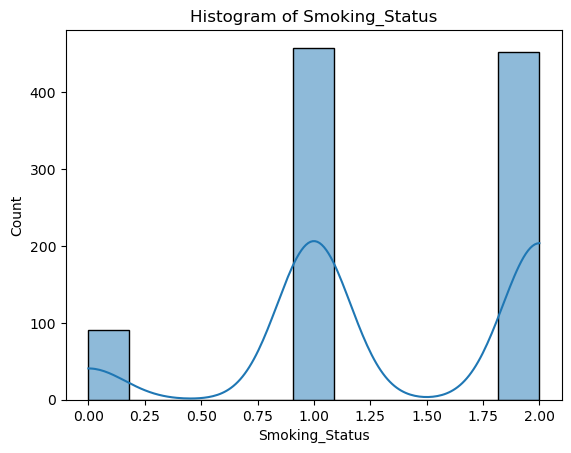

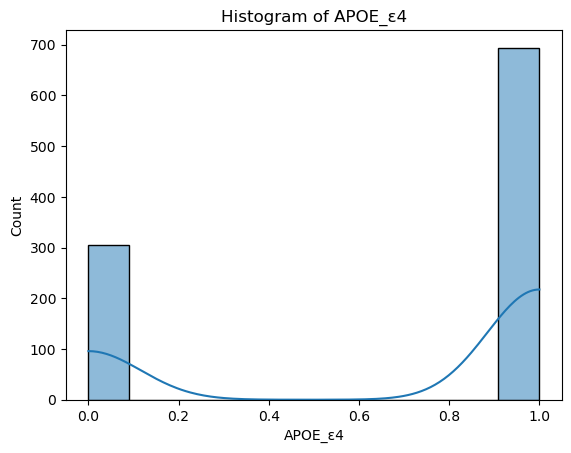

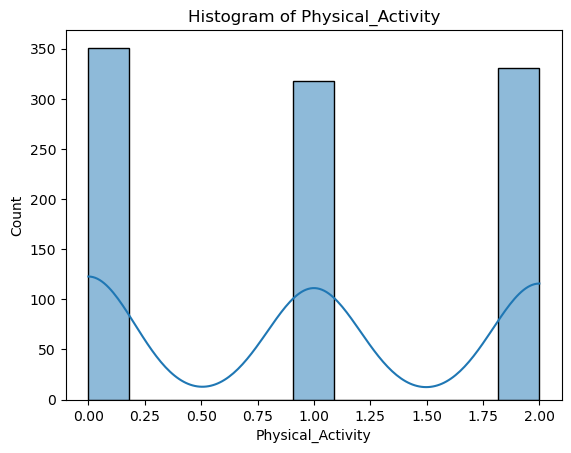

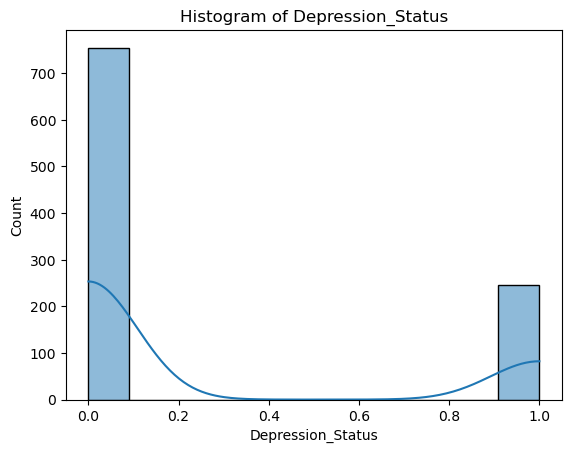

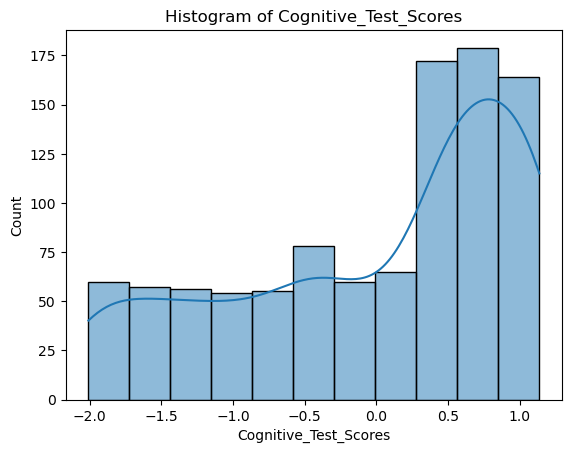

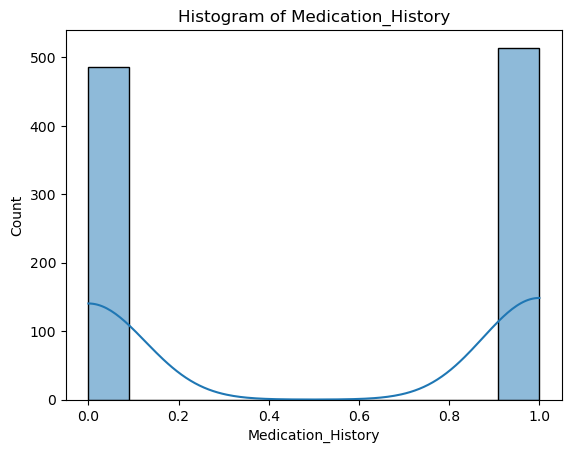

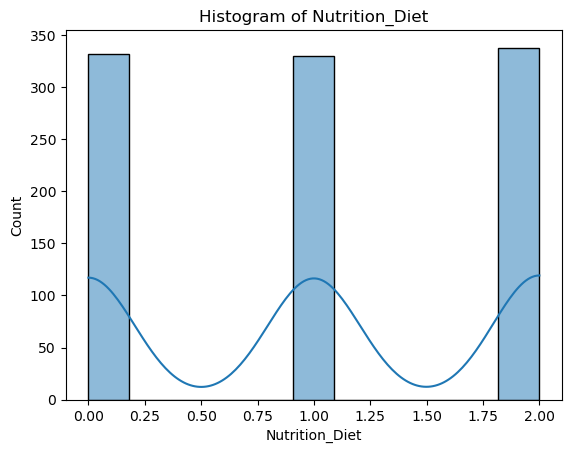

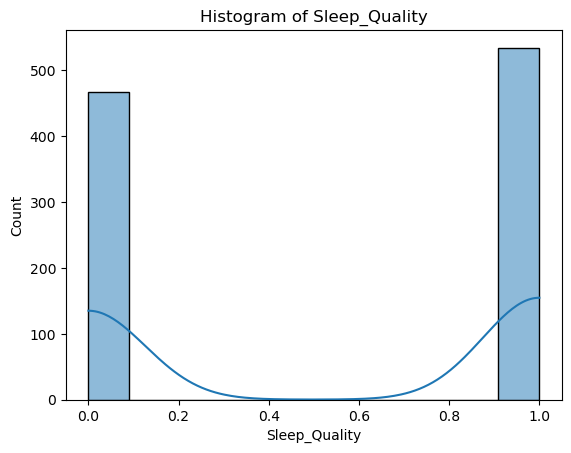

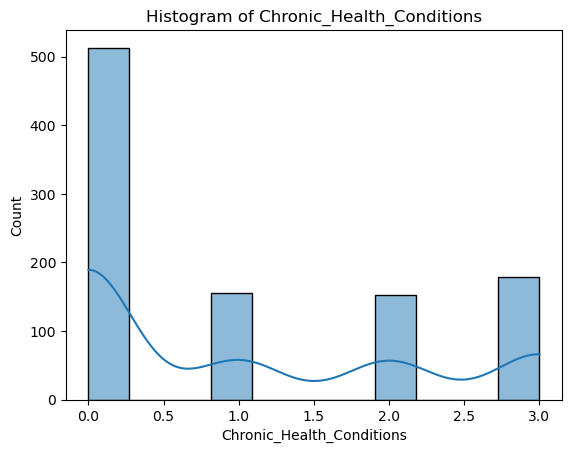

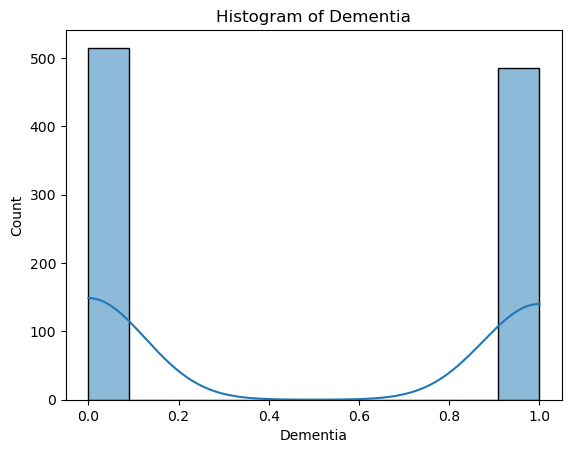

In [178]:
# Plotting histogram for all the numerical columns to know the distribution 
for column in numerical_columns:
    sns.histplot(data[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()

In [179]:
#Count plots for categorical columns
categorical_columns = data.select_dtypes(include='object').columns
for column in categorical_columns:
    sns.countplot(x=data[column])
    plt.title(f'Count Plot of {column}')
    plt.show()

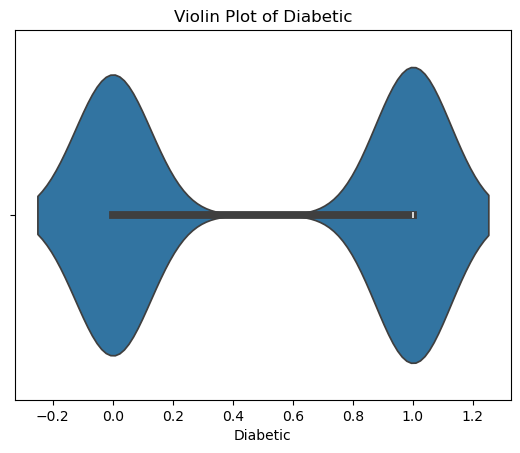

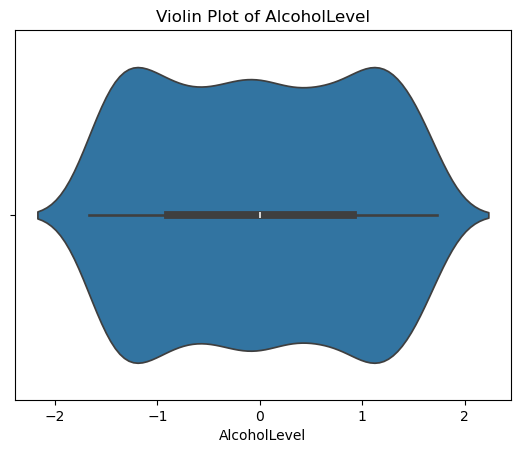

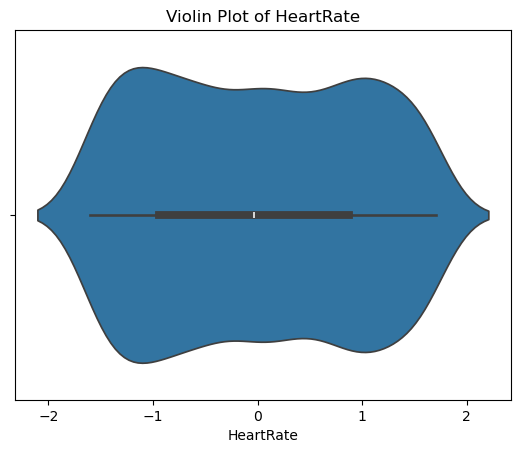

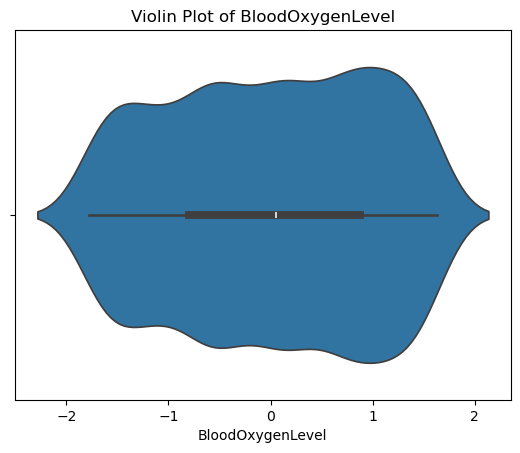

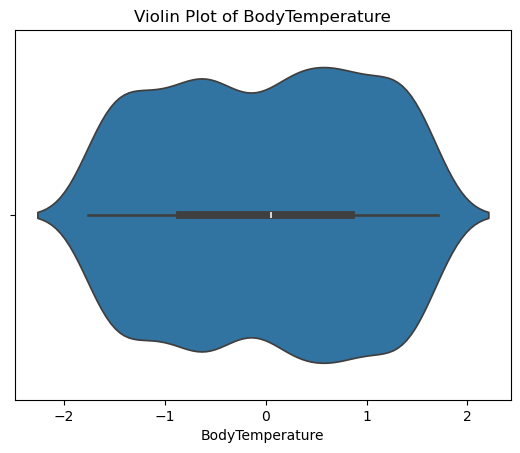

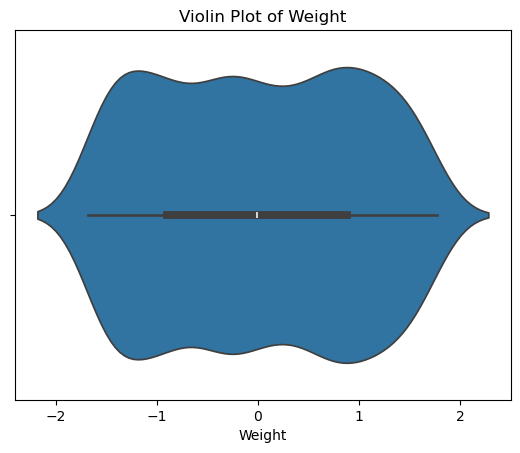

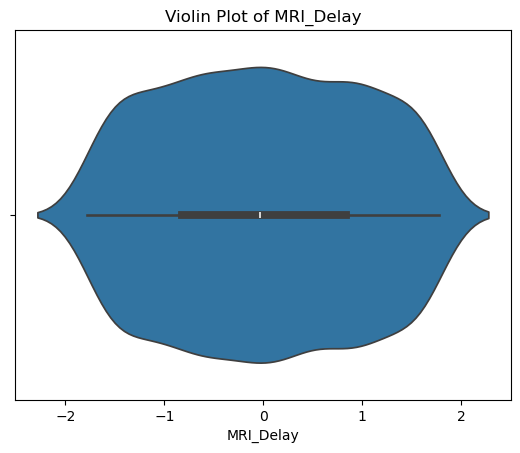

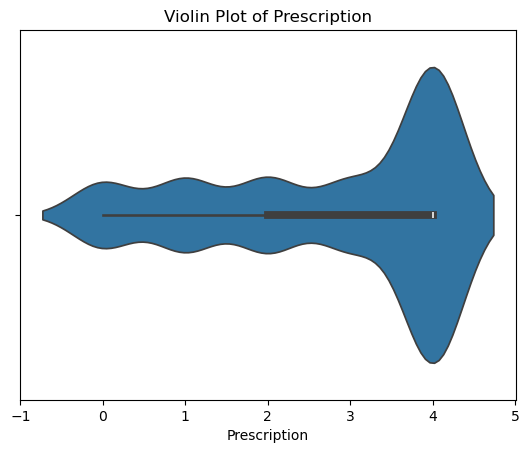

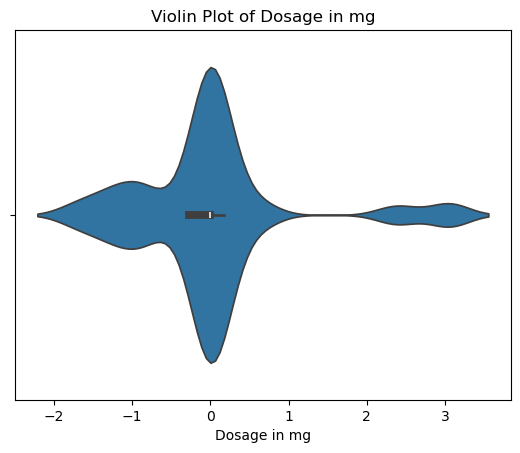

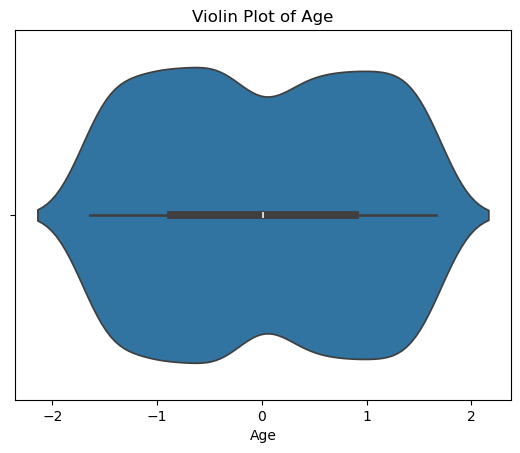

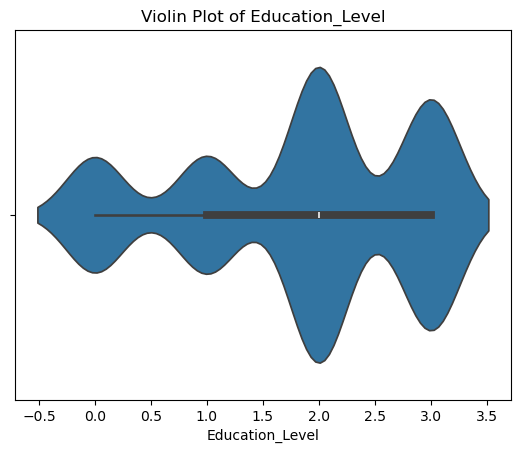

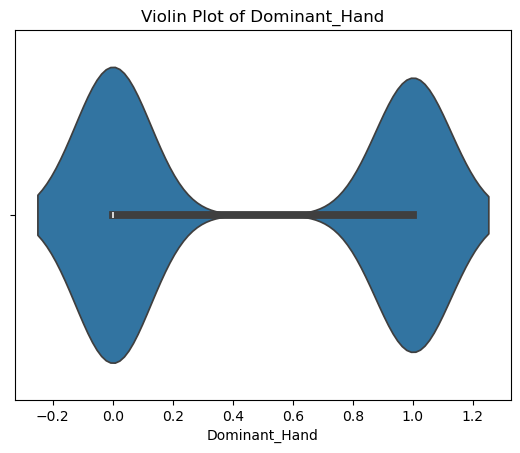

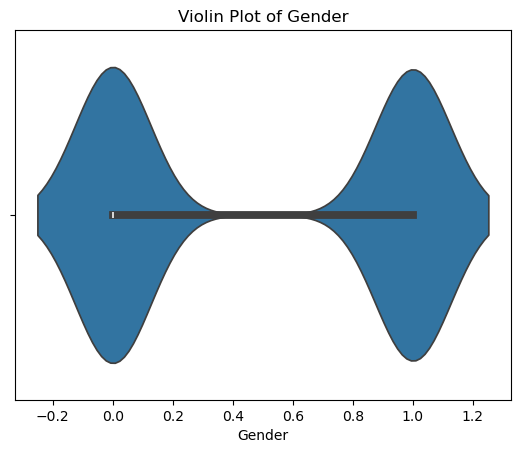

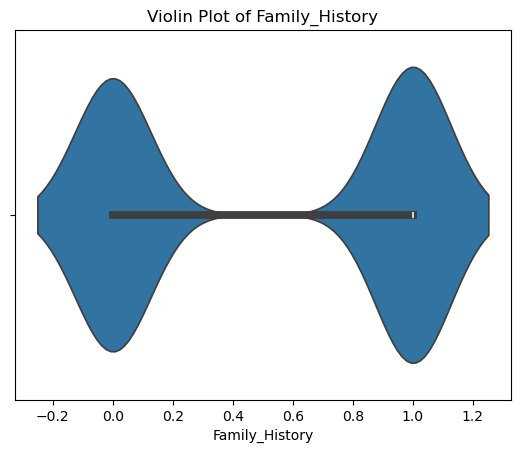

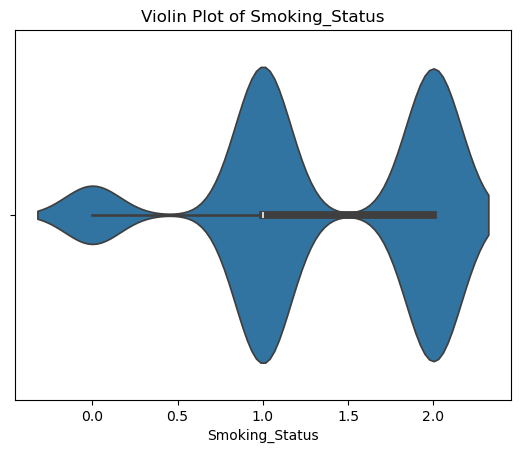

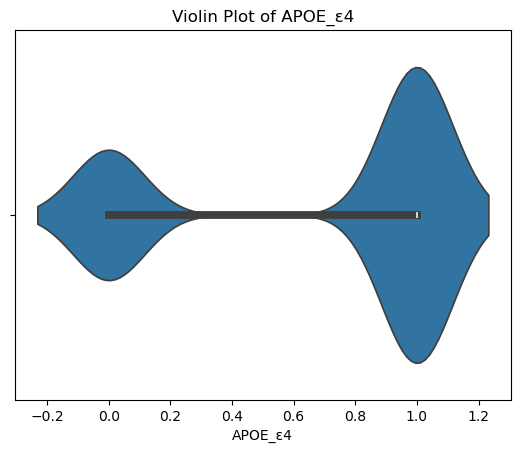

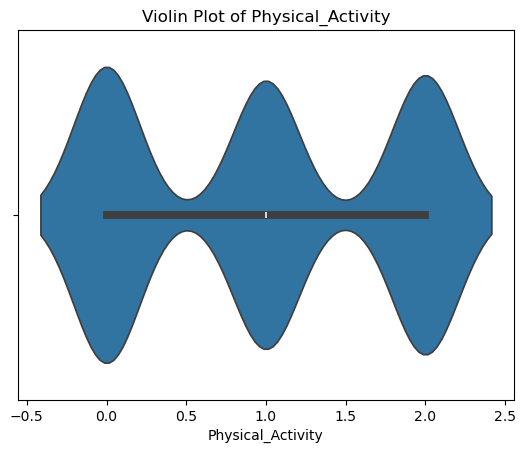

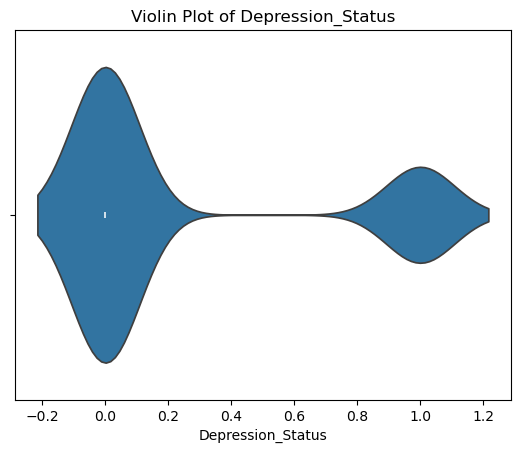

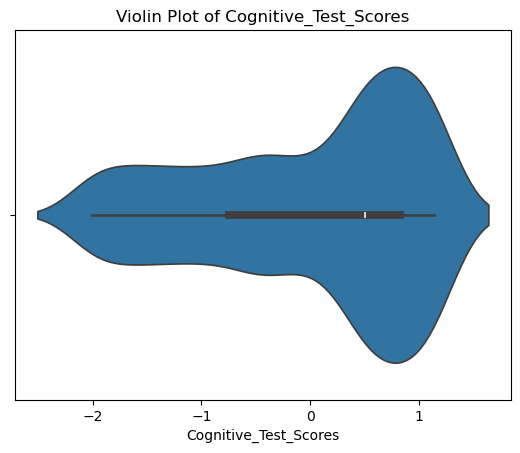

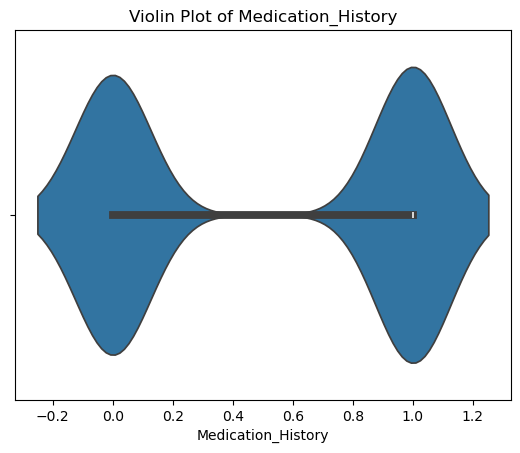

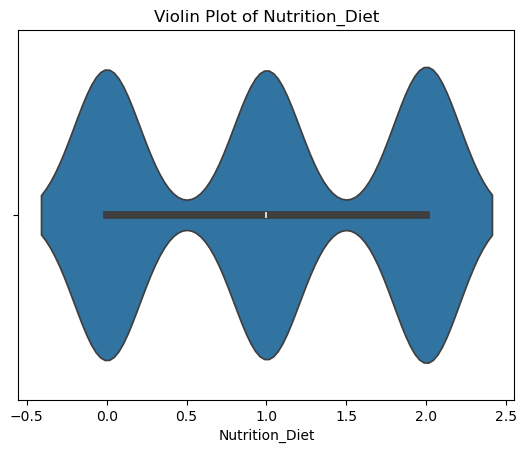

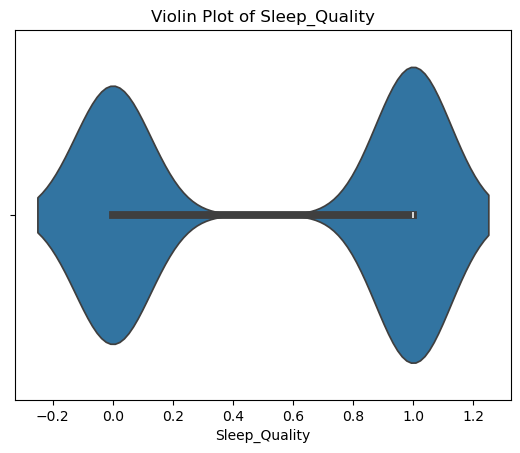

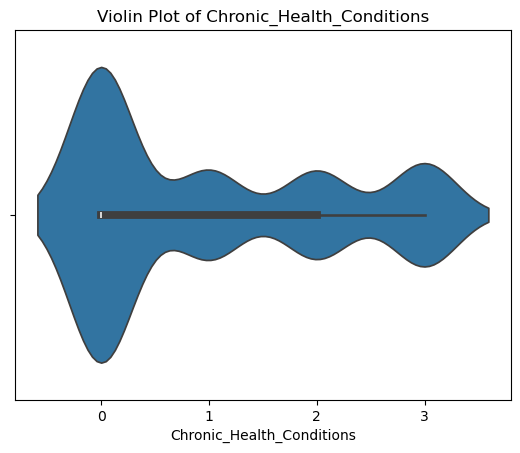

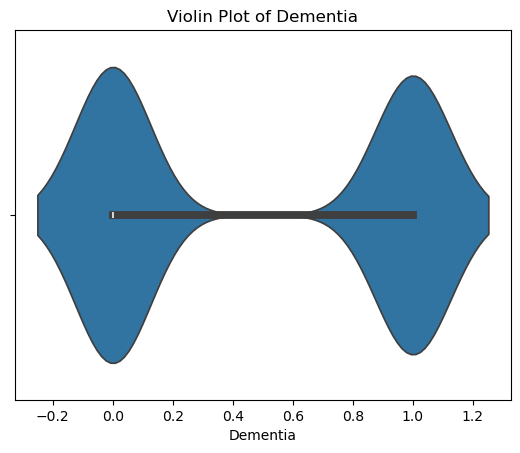

In [180]:
#Violin plot for knowing the data distribution , for checking spread and symmetry 
for column in numerical_columns:
    sns.violinplot(x=data[column])
    plt.title(f'Violin Plot of {column}')
    plt.show()

## Chi2 Test

In [181]:
model_rfe = LogisticRegression(max_iter=1000) #Importing of Logistic Regression model
model_rfe.fit(X_train[selected_features], y_train) # Training the model using training data and selected features
y_pred_rfe = model_rfe.predict(X_test[selected_features]) #Uisng test data, target is predicted
print("Shape of y_pred_rfe:", y_pred_rfe.shape)
from sklearn.metrics import confusion_matrix #Confusion matrix for checking prediction accuracy
from scipy.stats import chi2_contingency #Importing chi-square test function

#Converting y_test from 2D array to 1D 
y_test_flat = y_test.ravel() 

#Creating confusion matrix for comparing actual and predicted values
cm = confusion_matrix(y_test_flat, y_pred_rfe)

#Applying the Chi-Square test on confusion matrix
chi2, p, dof, expected = chi2_contingency(cm)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Shape of y_pred_rfe: (200,)
Chi-square statistic: 196.00569275405107
p-value: 1.554254656653571e-44
Degrees of freedom: 1
Expected frequencies:
 [[44.18 49.82]
 [49.82 56.18]]


#### Inference:
- The model made 200 predictions
- High Chi-square value of 196 is referring to the strong difference between actual and expected values/ is it randomly guessing
- p-value here extremely small value signifying high statistical significant and the model's prediction doesnt happened by random guessing
- Only one value can be changed independently in Confusion Matrix

In [183]:
#Using the trained logistic regression model for predicting dementia on test dataset using selected features
y_pred_rfe = model_rfe.predict(X_test[selected_features])
selected_features = X_train.columns[rfe.support_]
print(selected_features)

Index(['Diabetic', 'Prescription', 'Dosage in mg', 'Dominant_Hand',
       'Smoking_Status', 'APOE_ε4', 'Depression_Status',
       'Cognitive_Test_Scores', 'Sleep_Quality', 'Chronic_Health_Conditions'],
      dtype='object')


In [184]:
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred_rfe.shape)

Shape of y_test: (200, 1)
Shape of y_pred: (200,)


In [185]:

y_test_flat = y_test.ravel() #Converting 2D to 1D array

# Create a contingency table
contingency_table = pd.crosstab(y_test_flat, y_pred_rfe) #rows contains actual labels, columns contains predicted labels

# Perform the chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print chi-square test results
print("Chi-Square Statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies Table:")
print(expected)


Chi-Square Statistic: 196.00569275405107
P-value: 1.554254656653571e-44
Degrees of Freedom: 1
Expected Frequencies Table:
[[44.18 49.82]
 [49.82 56.18]]


#### Inferences:
- High Chi-square value of 196 is referring to the strong difference between actual and expected values
- p-value here extremely small value signifying high statistical significant
- Only one value can be changed independently

<h2 style="color:#000080;">Logistic Regression Model - without RFE</h2>

In [186]:
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

#Creating basic Logistic Regression model 
log_reg = LogisticRegression(C=1.0, penalty='l2', solver='liblinear')
log_reg.fit(X_train,y_train)

# Create a dictionary of hyperparameters to tune
param_grid = {'C': [0.1, 0.5, 1.0, 2.0, 5.0],
              'penalty': [None,'l2']}

# Create a GridSearchCV object, it tries all the combinations of hyperparameters
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=10, n_jobs=-1)

# Fit the grid search object to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_

# Print the best parameters
print("Best Parameters:", best_params)

# Fit the logistic regression model with the best parameters
log_reg_tuned = LogisticRegression(**best_params)
log_reg_tuned.fit(X_train, y_train)

y_pred_tuned = log_reg_tuned.predict(X_test)

Best Parameters: {'C': 2.0, 'penalty': 'l2'}


#### The best parameters are C = 2.0 and penalty = 'l2', these are used for training the final model

In [188]:
# Print classification report for more detailed evaluation
print(classification_report(y_test, y_pred_rfe))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Interpretation:
- All cases with dementia and no dementia is predicted correctly
- The overall accuracy is 100% which indicates that all the instances are correctly classified

In [191]:
from sklearn.metrics import cohen_kappa_score

# Compute Cohen's Kappa score
kappa_score = cohen_kappa_score(y_test, y_pred_rfe)

# Print Cohen's Kappa score
print("Cohen's Kappa Score:", kappa_score)

Cohen's Kappa Score: 1.0


#### Cohen's Kappa score measures how good is the model's prediction aligning with actual labels, values of 1 indicates that the prediction aligns with actual values

In [192]:
from sklearn.metrics import matthews_corrcoef, ConfusionMatrixDisplay

# Calculate Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred_rfe)

print(f'Matthews Correlation Coefficient: {mcc}')

Matthews Correlation Coefficient: 1.0


#### MCC is the most reliable metric used for classification

<h2 style="color:#000080;">Proposed Logistic Regression Model - with RFE</h2>

In [193]:
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

log_reg = LogisticRegression(C=0.5, penalty='l2', solver='liblinear')
log_reg.fit(X_train,y_train)

# Create the RFE object and rank each feature
rfe = RFE(estimator=log_reg, n_features_to_select=10, step=1)  #  n_features_to_select for keeping top 10 most important features
                                                               # step = removing 1 feature at a time during elimination
rfe = rfe.fit(X_train, y_train)

# Transform training and testing sets so only the selected features are retained
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Fit the logistic regression model on the transformed training set(only selected features are kept)
log_reg.fit(X_train_rfe, y_train)

# Make predictions on the transformed test set
y_pred_rfe = log_reg.predict(X_test_rfe)

# Evaluate the model
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)
precision_rfe = precision_score(y_test, y_pred_rfe)
recall_rfe = recall_score(y_test, y_pred_rfe)
f1_score_rfe = f1_score(y_test, y_pred_rfe)

# Print the evaluation metrics
print(f'Accuracy (RFE): {accuracy_rfe:.3f}')
print(f'Precision (RFE): {precision_rfe:.3f}')
print(f'Recall (RFE): {recall_rfe:.3f}')
print(f'F1-Score (RFE): {f1_score_rfe:.3f}')

Accuracy (RFE): 0.995
Precision (RFE): 1.000
Recall (RFE): 0.991
F1-Score (RFE): 0.995


#### Inferences:
- Accuracy denotes that  model correctly predicts 99.5% of test samples
- Perfect precision denotes no false positives
- High recall indicates only few cases of Dementia are missed
- F1 Score here shows that the model is highly reliable for detecting the dementia

<span style="color:red;font-weight:bold;">
Logistic Regression with RFE is more efficient than base model Logistic Regression since it only considers the most important features, doesnot cause overfitting and provides better generalization
</span>

### Cohens Kappa

In [194]:
from sklearn.metrics import cohen_kappa_score

# Compute Cohen's Kappa score
kappa_score = cohen_kappa_score(y_test, y_pred_rfe)

# Print Cohen's Kappa score
print("Cohen's Kappa Score:", kappa_score)

Cohen's Kappa Score: 0.9899699097291875


##### The high Cohen's Kappa Score indicates that model's predictions are highly reliable

### Matthews Correlation Coefficient

In [195]:
from sklearn.metrics import matthews_corrcoef, ConfusionMatrixDisplay

# Calculate Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred_rfe)

print(f'Matthews Correlation Coefficient: {mcc}')

Matthews Correlation Coefficient: 0.9900197103150592


##### Only low amount of misclassification

In [196]:
df['Gender'].value_counts()

Gender
Female    504
Male      496
Name: count, dtype: int64

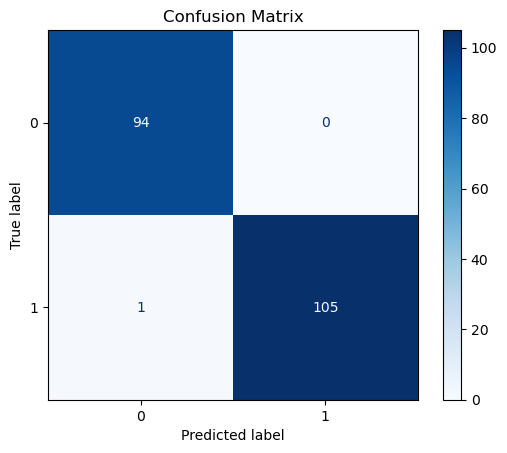

In [197]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred_rfe)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

#### Inferences:
- The True Negative have a value of 94 and it correctly predicted no dementia
- False Positive values are, 0 incorrectly predicted dementia
- False Negative value is 1 which is missed dementia case
- 105 values are true positive, which are correctly predicted as dementia

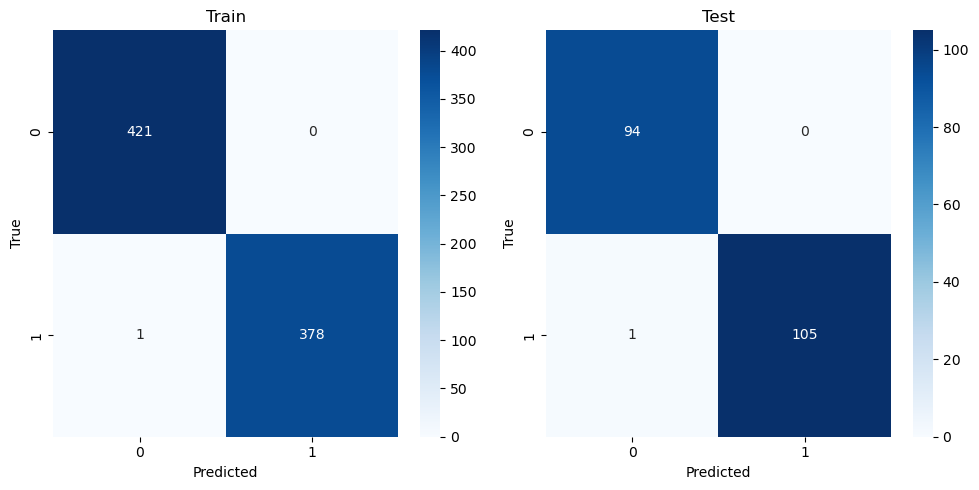

In [198]:
#Confusion matrices for comparing training data and testing data side-by-side
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Make predictions on the training set
y_train_pred = log_reg.predict(X_train_rfe)

# Compute the confusion matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)

# Compute the confusion matrix for testing data
cm_test = confusion_matrix(y_test, y_pred_rfe)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Create a heatmap for training data
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Train')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# Create a heatmap for testing data
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Test')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

#### Inferences:
- For training data, 421 patients without Dementia are correctly predicted as 0(True Negatives)
- No patients are wrongly predicted as having Dementia
- One patient with Dementia is wrongly predicted as No Dementia
- 378 patients with Dementia is correctly predicted as 1

- For testing data, for 94 patients, model correctly predicted as no dementia(True Negative)
-  No instance is wrongly marked as dementia(False Positives)
-  One dementia patient was missed(False Negative)
-  105 cases were correctly caught having dementia (True positives)

Cross-validation scores (tuned): [1.     0.9875 1.     1.     1.     0.9875 1.     0.9875 1.     1.    ]
Mean CV score (tuned): 0.9962500000000001


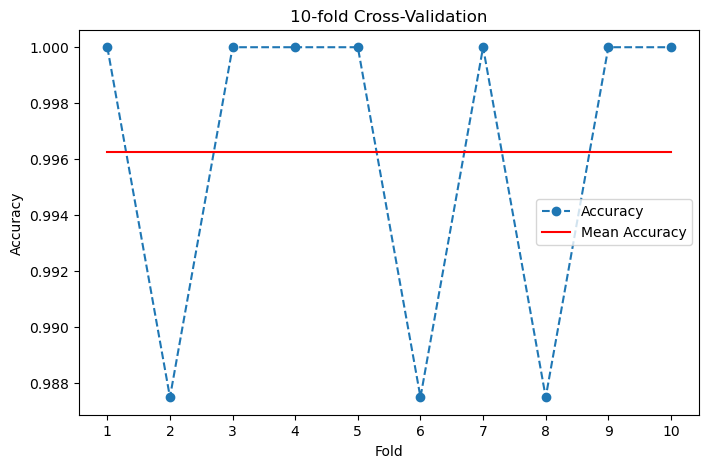

In [199]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=10)

print("Cross-validation scores (tuned):", cv_scores)
print("Mean CV score (tuned):", cv_scores.mean())

# Plot training details
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='--', label='Accuracy')
plt.plot(range(1, 11), [cv_scores.mean()] * 10, color='r', linestyle='-', label='Mean Accuracy')
plt.xticks(range(1, 11))
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-fold Cross-Validation')
plt.legend()
plt.show()

#### Inference:
- A 10-Fold cross validation technique is used here to check how well the model is performing on different oarts of dataset
- Blue dots represents accuracy score of the model on one fold
- The dashed line connects accuracy values to show the change happening across various folds

## ROC curve

AUC: 1.000


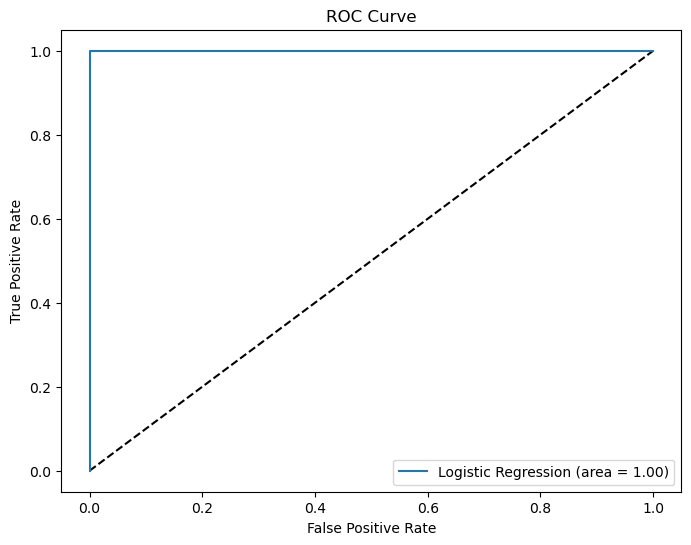

In [200]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


# Compute predicted probabilities: y_pred_prob
y_pred_prob = log_reg.predict_proba(X_test_rfe)[:,1]

# ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
average_precision = average_precision_score(y_test, y_pred_prob)

# Compute and print AUC score
roc_auc = auc(fpr, tpr)
print('AUC: {:.3f}'.format(roc_auc))

# Create ROC plot
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

#### Inference:
- The ROC curve is used to evaluate how well the Logistic Regression model differentiate between Dementia and Non-dementia
- The Y-axis denotes how much actual dementia cases were correctly predicted
- The X-axis denotes how many non-dementia cases were wrongly predicted as dementia
- Black dashed line shows random guessing
- Blue curve shows that model is good in identifying both classes

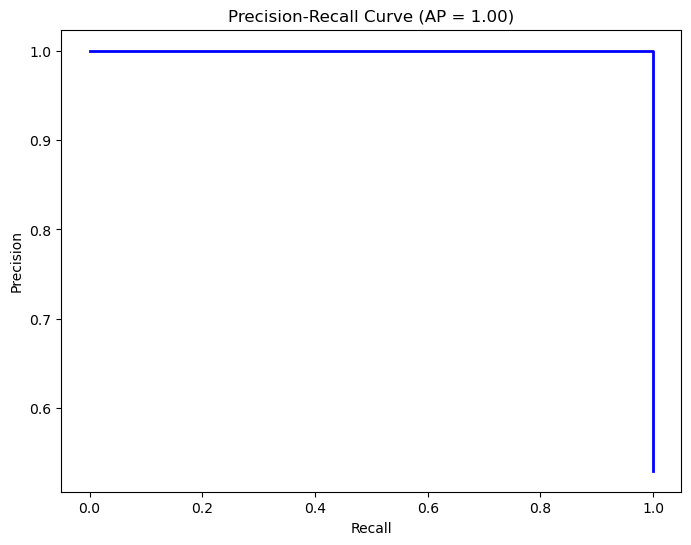

In [201]:
# Plotting the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {average_precision:.2f})')
plt.show()

#### The above Precision-Recall curve denotes that Dementia cases with 100% precision and 100% recall,  meaning no false negatives or false positives. Because of this, the curve stays at the top and Average Precision is 1.00, which indicates ideal model.

In [202]:
#Training the logistic regression model- 50 epochs
from sklearn.metrics import log_loss

# Lists to store training and testing accuracy values
train_accuracy_values = []
test_accuracy_values = []
# Lists to store training and testing loss values
train_loss_values = []
test_loss_values = []
# Train the model for 20 epochs
for epoch in range(1, 51):
    log_reg.fit(X_train_rfe, y_train)
    # Evaluate on train and test data
    train_accuracy = accuracy_score(y_train, log_reg.predict(X_train_rfe))
    test_accuracy = accuracy_score(y_test, log_reg.predict(X_test_rfe))
    train_loss = log_loss(y_train, log_reg.predict_proba(X_train_rfe))
    test_loss = log_loss(y_test, log_reg.predict_proba(X_test_rfe))
    # Append accuracy and loss values to lists
    train_accuracy_values.append(train_accuracy)
    test_accuracy_values.append(test_accuracy)
    train_loss_values.append(train_loss)
    test_loss_values.append(test_loss)
    print(f"Epoch {epoch}: Train accuracy - {train_accuracy:.4f}, Test accuracy - {test_accuracy:.4f}, "
          f"Train loss - {train_loss:.4f}, Test loss - {test_loss:.4f}")

Epoch 1: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 2: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 3: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 4: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 5: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 6: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 7: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 8: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 9: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 10: Train accuracy - 0.9988, Test accuracy - 0.9950, Train loss - 0.0263, Test loss - 0.0243
Epoch 11: Train acc

##### The train accuracy is 0.9988 and Test Accuracy is 0.9950, Train loss is around 0.0263 and Test Loss is 0.0243 which remain constant and low. Here the model achieves high performance from first to end, since model had learned all the patterns in the data.


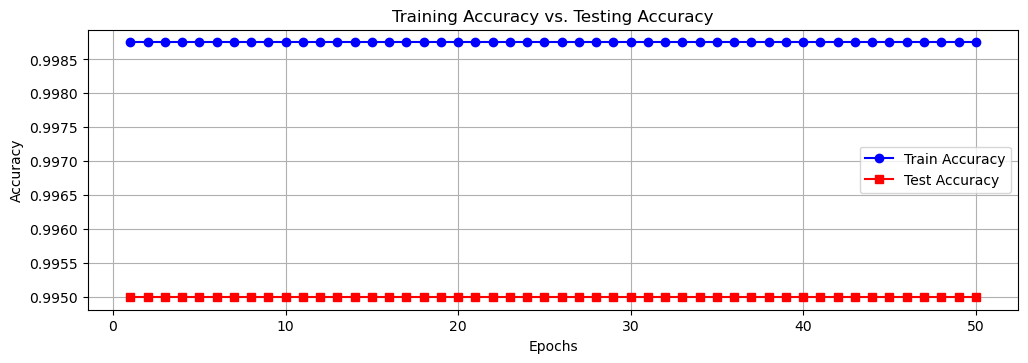

In [203]:
# Plot training accuracy vs. testing accuracy
epochs = np.arange(1, 51)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs, train_accuracy_values, marker='o', label='Train Accuracy', linestyle='-', color='b')
plt.plot(epochs, test_accuracy_values, marker='s', label='Test Accuracy', linestyle='-', color='r')
plt.title("Training Accuracy vs. Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

- Model's train and test accuracies remain consistently through out. The model is stable and performs well.
- This indicates that the model is highly stable, it performs reliable on both training and
  testing data.

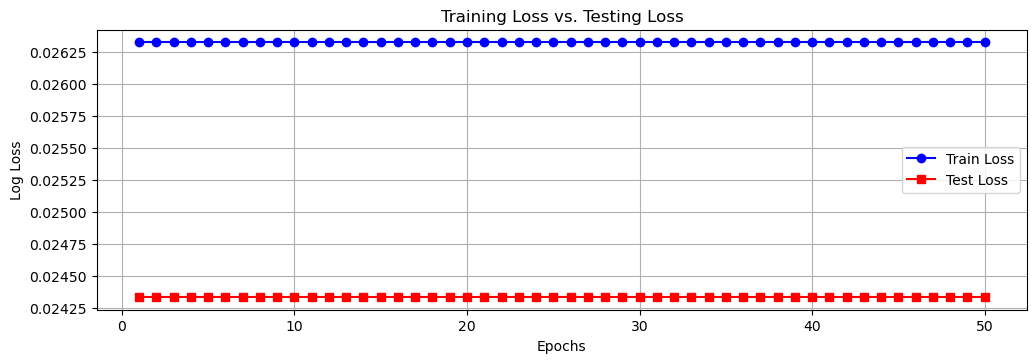

In [204]:
# Plot training loss vs. testing loss
epochs = np.arange(1, 51)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 2)
plt.plot(epochs, train_loss_values, marker='o', label='Train Loss', linestyle='-', color='b')
plt.plot(epochs, test_loss_values, marker='s', label='Test Loss', linestyle='-', color='r')
plt.title("Training Loss vs. Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.grid(True)
plt.legend()
plt.show()

- Here loss is very low and it is almost constant which indicates that model is highly stable and accurate
- Model reached the optimal performance in quick manner.

In [205]:
data[data['Gender'] == 0]['Dementia'].value_counts()

Dementia
0    260
1    244
Name: count, dtype: int64

- Here for Gender = 0(males), 260 does not have dementia, 244 have dementia

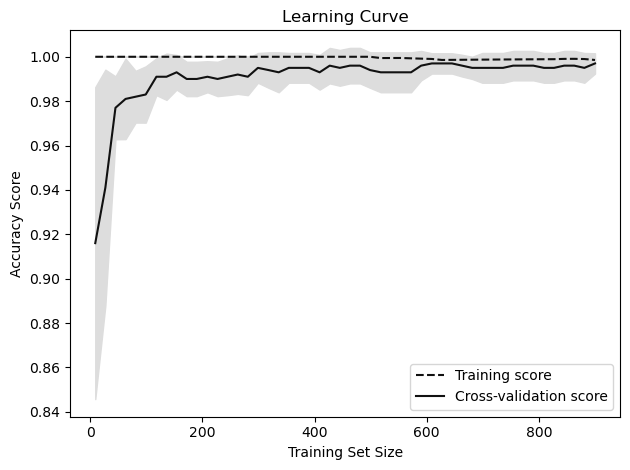

In [206]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(log_reg, X, y, cv=10, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.01, 1.0, 50))

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.plot(train_sizes, train_mean, '--', color="#111111",  label="Training score")
plt.plot(train_sizes, test_mean, color="#111111", label="Cross-validation score")

# Draw bands
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="#DDDDDD")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="#DDDDDD")

# Create plot
plt.title("Learning Curve")
plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc="best")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- There are two lines here, dotted line is training score(Accuracy on training data) and other is cross-validation score(Accuracy on unseen data for validation)
- Here we can see both the lines are closer which means, the model performance is high


<h2 style="color:#000080;">SHAP</h2>

In [207]:
import shap

# Initialize JavaScript visualizations
shap.initjs()

In [208]:
# Create an explainer object 
explainer = shap.LinearExplainer(log_reg, X_train_rfe)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_rfe) 
# To test data , it tells how much each feature push the model towards Dementia(1) and No dementia(0)

In [209]:
# Get the feature names
feature_names = np.array(X_train.columns)
selected_features = feature_names[rfe.support_] #which all features RFE has kept

In [210]:
#Converting RFE data into pandas DataFrame and assigning appropriate feature names as the columns
X_train_rfe = pd.DataFrame(X_train_rfe, columns=selected_features)
X_test_rfe = pd.DataFrame(X_test_rfe, columns=selected_features)

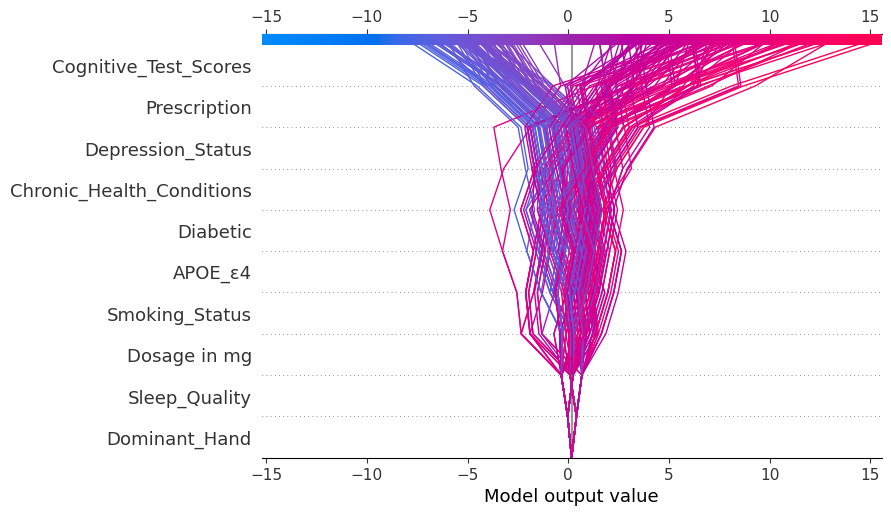

In [211]:
fig = plt.figure()
shap.decision_plot(explainer.expected_value, shap_values, X_test_rfe)
plt.show()

### Inferences
- Each line represent each patient
- Here Pink/Red lines indicates high feature values
- Blue lines represents lower feature values
- The top features have most impact on the model
- For cognitive test scores, red line towards right indicates that high test scores increases dementia prediction and left indicates that low scores reduce dementia probability

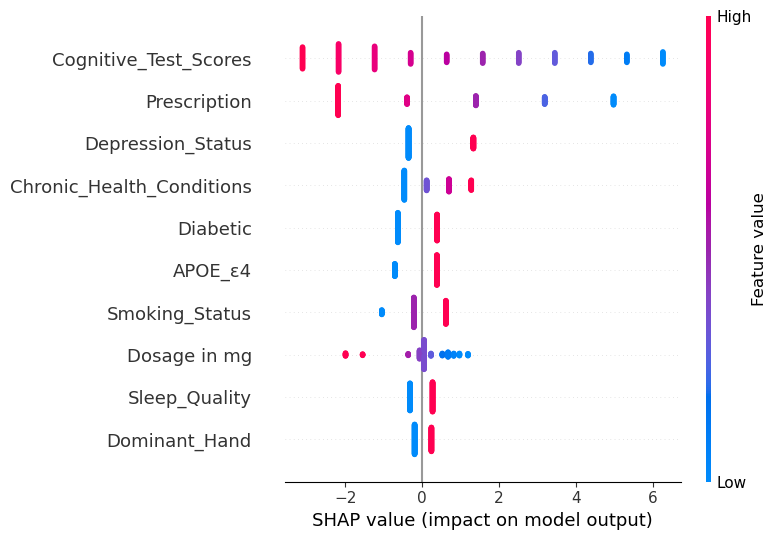

In [212]:
fig = plt.figure()
shap.summary_plot(shap_values, X_test_rfe)
plt.show()

### Inference:
- Top most features have high impact on prediction and features that are low have less influence
- Positive SHAP value(Red) indicates prediction towards Dementia
- Negative SHAP value(Blue) indicates prediction towards No Dementia
- An example, low cognitive test scores contribute high towards the prediction of dementia(blue colour)

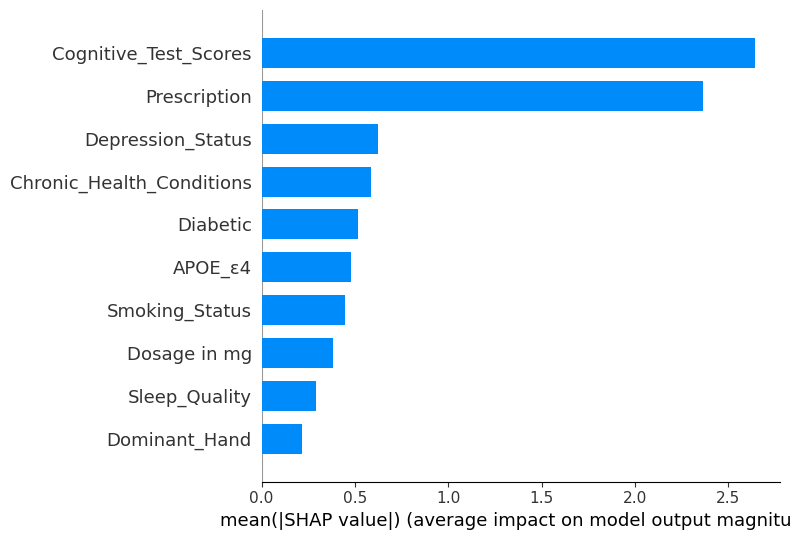

In [213]:
shap.summary_plot(shap_values, X_test_rfe, plot_type="bar")

#### Cognitive test scores and prescription have the highest average impact on the model’s predictions, followed by depression status and chronic health conditions.

In [214]:
shap.initjs()
#fig = plt.figure()
i = 1
shap.force_plot(explainer.expected_value, shap_values[i,:], X_test_rfe.iloc[i,:])

- The features in Red increases the probability a patient will have dementia and features in blue decreases the probability of getting dementia
- Base value: 0.1668 is average model output for all the samples.
- f(x): 4.53 is the final prediction for a specific person which denotes dementia strongly

In [215]:
X_train_rfe.shape

(800, 10)

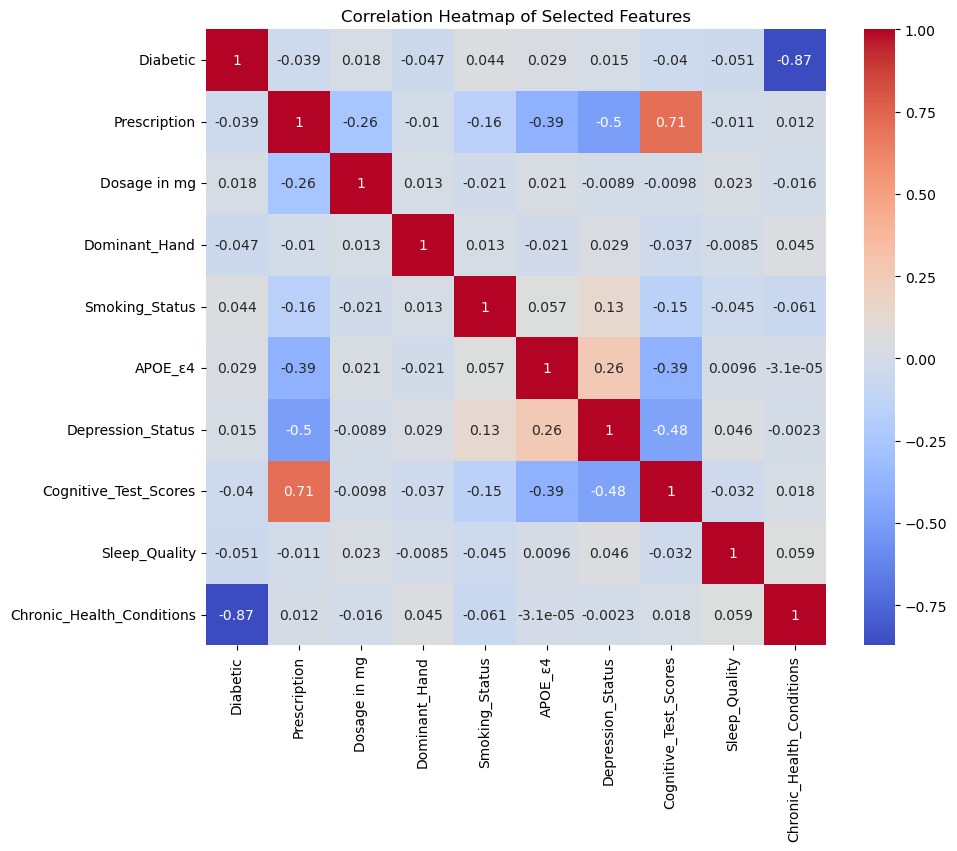

In [216]:
# Checking the correlation between the selected features post RFE and visualizing it for detect multicollinearity
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'X_train_rfe' is defined
# Calculate the correlation matrix for the selected features
selected_features = X_train.columns[rfe.support_]
X_train_rfe = X_train[selected_features]      # this is already a DataFrame

corr_matrix = X_train_rfe.corr()


# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Selected Features')
plt.show()


### Inference:
- Diabetic and Chronic_Health_Conditions shows high negative correlation(-0.87), if diabetic=1 the Chronic_Health_Conditions can be low and this can lead to redundancy
- Prescription vand Cognitive_Test_Scoreshas strong positive correlation(0.71)
- Depression_Status and Cognitive_Test_Scores(0.48), this is a moderate negative correlation.Here, higher depression relates to less cognitive test scores
- Other than these most features are independent and can be taken for modelling